In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/glove-global-vectors-for-word-representation


In [2]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

class JigsawPreprocessor:
    """
    Preprocessor for Jigsaw Unintended Bias in Toxicity Classification dataset
    """
    
    def __init__(self):
        self.identity_columns = [
            'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
            'muslim', 'black', 'white', 'psychiatric_or_mental_illness', 'asian',
            'atheist', 'bisexual', 'buddhist', 'heterosexual', 'hindu',
            'intellectual_or_learning_disability', 'latino', 'other_disability',
            'other_gender', 'other_race_or_ethnicity', 'other_religion',
            'other_sexual_orientation', 'physical_disability', 'transgender'
        ]
        
        self.toxicity_subtypes = [
            'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat'
        ]
        
    def load_data(self, train_path, test_path):
        """Load train and test datasets"""
        print("Loading datasets...")
        self.train_df = pd.read_csv(train_path)
        self.test_df = pd.read_csv(test_path)
        print(f"Train shape: {self.train_df.shape}")
        print(f"Test shape: {self.test_df.shape}")
        return self.train_df, self.test_df
    
    def clean_text(self, text):
        """Clean and normalize text"""
        if pd.isna(text):
            return ""
        
        # Convert to string and lowercase
        text = str(text).lower()
        
        # Remove newlines and tabs
        text = text.replace('\n', ' ').replace('\t', ' ')
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        
        # Remove special characters but keep punctuation that might be important
        text = re.sub(r'[^a-zA-Z0-9\s\.\!\?\,]', ' ', text)
        
        # Remove extra whitespace
        text = ' '.join(text.split())
        
        return text
    
    def handle_missing_values(self, df, is_train=True):
        """Handle missing values in the dataset"""
        print("\nHandling missing values...")
        
        # For comment_text, fill with empty string
        df['comment_text'] = df['comment_text'].fillna('')
        
        if is_train:
            # Fill target with median (though it should not have missing values)
            if df['target'].isna().any():
                df['target'] = df['target'].fillna(df['target'].median())
            
            # Fill toxicity subtypes with 0 (assuming no annotation means not toxic)
            for col in self.toxicity_subtypes:
                if col in df.columns:
                    df[col] = df[col].fillna(0)
            
            # Fill identity columns with 0 (no mention)
            for col in self.identity_columns:
                if col in df.columns:
                    df[col] = df[col].fillna(0)
            
            # Fill other numeric columns
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if df[col].isna().any():
                    df[col] = df[col].fillna(0)
        
        return df
    
    def create_target_labels(self, df):
        """Create binary target labels for classification"""
        print("\nCreating target labels...")
        
        # Binary classification: toxic (>=0.5) vs non-toxic (<0.5)
        df['target_binary'] = (df['target'] >= 0.5).astype(int)
        
        # Create multi-label targets for toxicity subtypes
        for col in self.toxicity_subtypes:
            if col in df.columns:
                df[f'{col}_binary'] = (df[col] >= 0.5).astype(int)
        
        return df
    
    def create_identity_features(self, df):
        """Create aggregated identity features"""
        print("\nCreating identity features...")
        
        # Check if any identity is mentioned
        identity_cols_present = [col for col in self.identity_columns if col in df.columns]
        
        if identity_cols_present:
            df['any_identity'] = (df[identity_cols_present] >= 0.5).any(axis=1).astype(int)
            df['identity_count'] = (df[identity_cols_present] >= 0.5).sum(axis=1)
        
        return df
    
    def create_text_features(self, df):
        """Create basic text-based features"""
        print("\nCreating text features...")
        
        df['text_length'] = df['comment_text'].apply(len)
        df['word_count'] = df['comment_text'].apply(lambda x: len(str(x).split()))
        df['unique_word_count'] = df['comment_text'].apply(lambda x: len(set(str(x).split())))
        df['char_count'] = df['comment_text'].apply(lambda x: len(str(x)))
        df['punctuation_count'] = df['comment_text'].apply(lambda x: sum([1 for c in str(x) if c in string.punctuation]))
        df['capital_count'] = df['comment_text'].apply(lambda x: sum([1 for c in str(x) if c.isupper()]))
        df['exclamation_count'] = df['comment_text'].apply(lambda x: str(x).count('!'))
        df['question_count'] = df['comment_text'].apply(lambda x: str(x).count('?'))
        
        # Average word length
        df['avg_word_length'] = df['comment_text'].apply(
            lambda x: np.mean([len(word) for word in str(x).split()]) if len(str(x).split()) > 0 else 0
        )
        
        return df
    
    def remove_irrelevant_columns(self, df, is_train=True):
        """Remove columns that are not useful for modeling"""
        print("\nRemoving irrelevant columns...")
        
        cols_to_drop = []
        
        # Metadata columns that won't help with toxicity prediction
        metadata_cols = ['created_date', 'publication_id', 'parent_id', 'article_id']
        for col in metadata_cols:
            if col in df.columns:
                cols_to_drop.append(col)
        
        # Engagement metrics (rating, funny, wow, sad, likes, disagree)
        # These might be outcomes rather than predictors
        engagement_cols = ['rating', 'funny', 'wow', 'sad', 'likes', 'disagree']
        for col in engagement_cols:
            if col in df.columns:
                cols_to_drop.append(col)
        
        # Annotator counts - keep these as they might indicate agreement/uncertainty
        # annotator_cols = ['identity_annotator_count', 'toxicity_annotator_count']
        
        if cols_to_drop:
            df = df.drop(columns=cols_to_drop, errors='ignore')
            print(f"Dropped columns: {cols_to_drop}")
        
        return df
    
    def preprocess(self, train_path, test_path, sample_size=None):
        """
        Complete preprocessing pipeline
        
        Args:
            train_path: Path to training CSV
            test_path: Path to test CSV
            sample_size: If provided, use a sample of training data for faster processing
        
        Returns:
            train_df, test_df: Preprocessed dataframes
        """
        # Load data
        train_df, test_df = self.load_data(train_path, test_path)
        
        # Sample if requested (useful for development)
        if sample_size and sample_size < len(train_df):
            print(f"\nSampling {sample_size} rows from training data...")
            train_df = train_df.sample(n=sample_size, random_state=42)
        
        # Clean text
        print("\nCleaning text...")
        train_df['comment_text_clean'] = train_df['comment_text'].apply(self.clean_text)
        test_df['comment_text_clean'] = test_df['comment_text'].apply(self.clean_text)
        
        # Handle missing values
        train_df = self.handle_missing_values(train_df, is_train=True)
        test_df = self.handle_missing_values(test_df, is_train=False)
        
        # Create target labels (only for train)
        train_df = self.create_target_labels(train_df)
        
        # Create identity features
        train_df = self.create_identity_features(train_df)
        test_df = self.create_identity_features(test_df)
        
        # Create text features
        train_df = self.create_text_features(train_df)
        test_df = self.create_text_features(test_df)
        
        # Remove irrelevant columns
        train_df = self.remove_irrelevant_columns(train_df, is_train=True)
        test_df = self.remove_irrelevant_columns(test_df, is_train=False)
        
        print("\n" + "="*50)
        print("PREPROCESSING COMPLETE")
        print("="*50)
        print(f"\nFinal train shape: {train_df.shape}")
        print(f"Final test shape: {test_df.shape}")
        
        # Show class distribution
        if 'target_binary' in train_df.columns:
            print(f"\nTarget distribution:")
            print(train_df['target_binary'].value_counts(normalize=True))
        
        return train_df, test_df
    
    def save_processed_data(self, train_df, test_df, output_dir='./'):
        """Save preprocessed data"""
        print("\nSaving preprocessed data...")
        train_df.to_csv(f'{output_dir}train_preprocessed.csv', index=False)
        test_df.to_csv(f'{output_dir}test_preprocessed.csv', index=False)
        print("Data saved successfully!")


# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    # Initialize preprocessor
    preprocessor = JigsawPreprocessor()
    
    # Define file paths (adjust these to your Kaggle notebook paths)
    train_path = '/kaggle/input/jigsaw-unintended-bias-in-toxicity-classification/train.csv'
    test_path = '/kaggle/input/jigsaw-unintended-bias-in-toxicity-classification/test.csv'
    
    # Preprocess data
    # Use sample_size parameter for quick testing (e.g., sample_size=10000)
    # Remove or set to None for full dataset
    train_processed, test_processed = preprocessor.preprocess(
        train_path=train_path,
        test_path=test_path,
        sample_size=None  # Set to a smaller number for testing, e.g., 50000
    )
    
    # Save processed data
    preprocessor.save_processed_data(train_processed, test_processed)
    
    # Display info
    print("\nTrain columns:", train_processed.columns.tolist())
    print("\nFirst few rows of processed training data:")
    print(train_processed.head())
    
    print("\n" + "="*50)
    print("KEY COLUMNS FOR MODELING")
    print("="*50)
    print("\nText column: 'comment_text_clean'")
    print("Target column: 'target_binary' (0=non-toxic, 1=toxic)")
    print("Original target: 'target' (continuous 0-1)")
    print("\nIdentity columns available:", preprocessor.identity_columns)
    print("Toxicity subtype columns:", preprocessor.toxicity_subtypes)

Loading datasets...
Train shape: (1804874, 45)
Test shape: (97320, 2)

Cleaning text...

Handling missing values...

Handling missing values...

Creating target labels...

Creating identity features...

Creating identity features...

Creating text features...

Creating text features...

Removing irrelevant columns...
Dropped columns: ['created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree']

Removing irrelevant columns...

PREPROCESSING COMPLETE

Final train shape: (1804874, 53)
Final test shape: (97320, 12)

Target distribution:
target_binary
0    0.920031
1    0.079969
Name: proportion, dtype: float64

Saving preprocessed data...
Data saved successfully!

Train columns: ['id', 'target', 'comment_text', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_dis

2026-01-29 09:57:21.049211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769680641.235686      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769680641.288545      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading preprocessed data...
Original train shape: (1804874, 53)
Original test shape: (97320, 12)
Target distribution:
target_binary
0    0.920031
1    0.079969
Name: proportion, dtype: float64

Sampling 100000 rows for training...
Sampled train shape: (100000, 53)

BATHE MODEL TRAINING PIPELINE (100k Sampling / Standard Loss)
Preparing data...
Note: Identity columns missing in test set. Creating zero-placeholders for 24 features.
Tokenizing text...
Training samples: 80000
Validation samples: 20000
Test samples: 97320
Vocabulary size: 73640

Building CNN Model...


I0000 00:00:1769680686.042571      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Training CNN (Standard Loss)
Epoch 1/7


I0000 00:00:1769680692.305996      59 service.cc:148] XLA service 0x7dcd9c003e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769680692.306549      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769680692.862435      59 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/313 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.6684 - auc: 0.4944 - loss: 0.6178 - precision: 0.0781 - recall: 0.3376   

I0000 00:00:1769680699.045395      59 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.9135 - auc: 0.6213 - loss: 0.2816 - precision: 0.3203 - recall: 0.0645 - val_accuracy: 0.9401 - val_auc: 0.9265 - val_loss: 0.1561 - val_precision: 0.7988 - val_recall: 0.3352 - learning_rate: 0.0010
Epoch 2/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9468 - auc: 0.9398 - loss: 0.1403 - precision: 0.7640 - recall: 0.4895 - val_accuracy: 0.9420 - val_auc: 0.9228 - val_loss: 0.1603 - val_precision: 0.7620 - val_recall: 0.3984 - learning_rate: 0.0010
Epoch 3/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9613 - auc: 0.9741 - loss: 0.0971 - precision: 0.8087 - recall: 0.6806
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.9614 - auc: 0.9741 - loss: 0.0971 - precision: 0.8087 - recall: 0.6808 - val_accuracy: 0.9364 - val_auc: 0.8968 - val_loss: 0.1924 - val_precision: 0.6355 - val_recall: 0.4797 - learning_rate: 0.0010
Epoch 

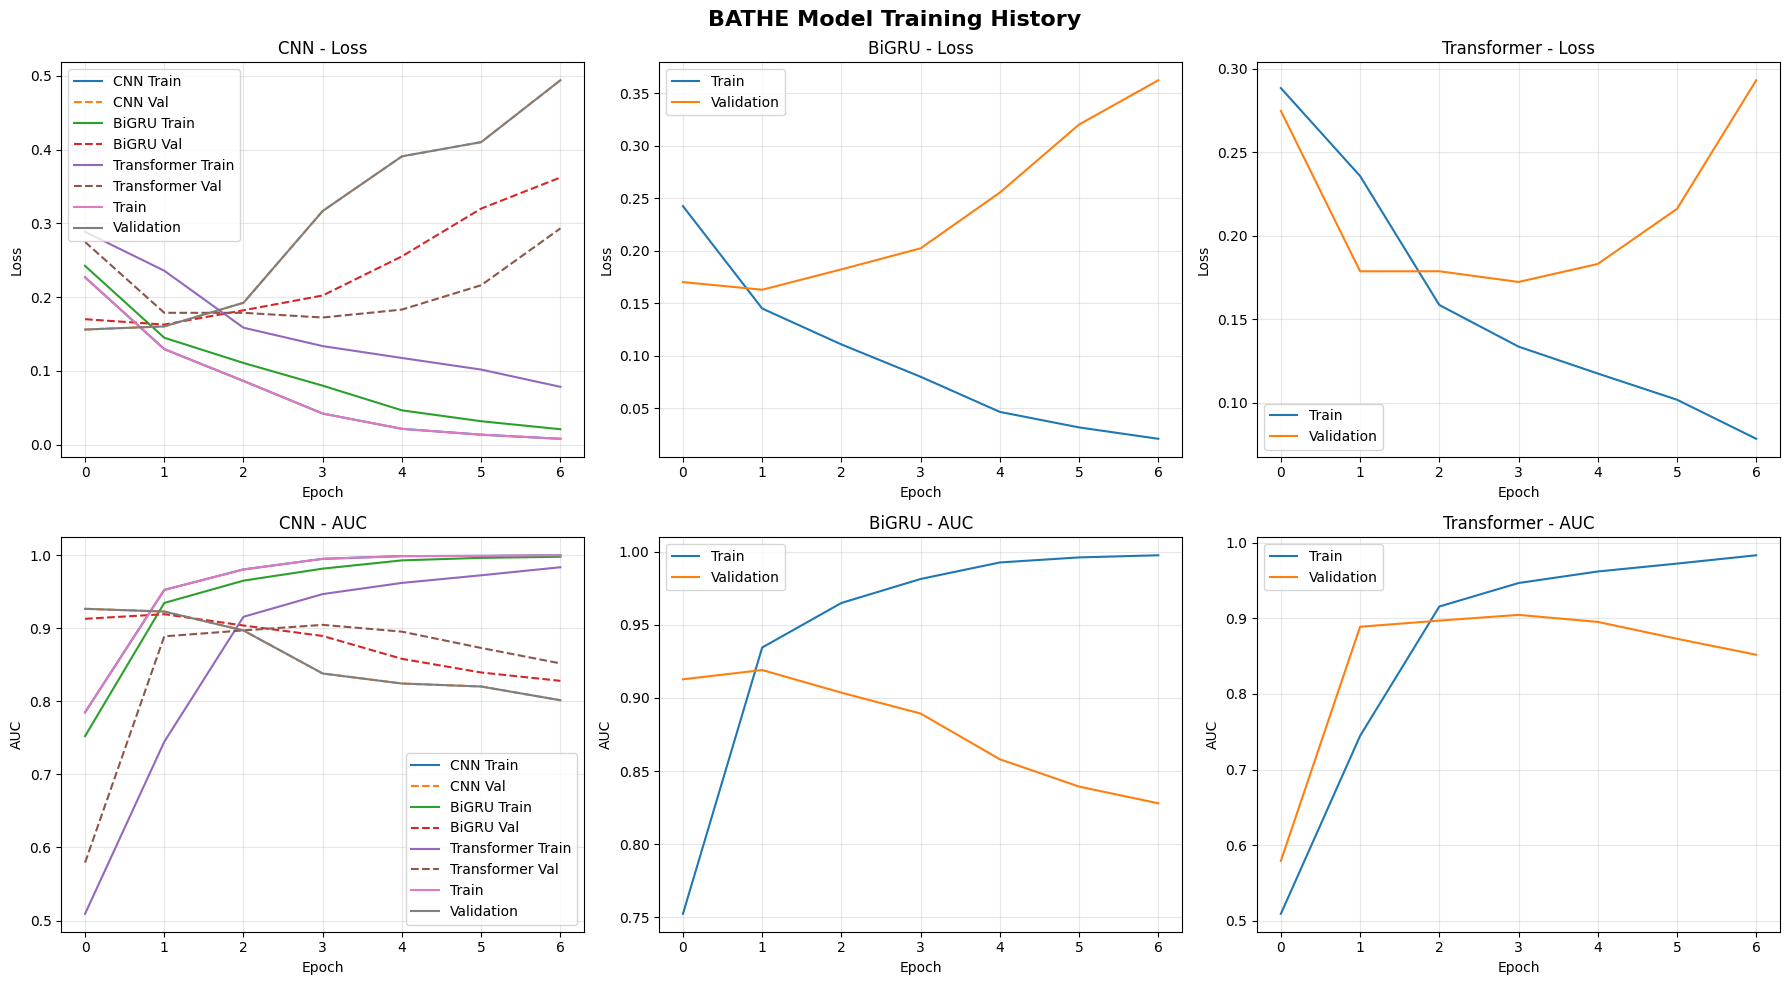


GENERATING PREDICTIONS
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

BIAS EVALUATION ACROSS IDENTITY GROUPS

                      Identity  Samples      AUC  F1-Score
                         male      493 0.502083  0.061224
                       female      621 0.500084  0.061538
    homosexual_gay_or_lesbian      123 0.419176  0.105263
                    christian      441 0.500588  0.062500
                       jewish       88 0.497587  0.000000
                       muslim      233 0.435827  0.059701
                        black      173 0.424631  0.114286
                        white      315 0.521913  0.083333
psychiatric_or_mental_illness       53 0.361111  0.000000
                        asian       54 0.521591  0.142857
                      atheist       19 0.335714  0.000000
                 heterosexual       19 0.500000  0.000000
     

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class BATHEModel:
    """
    BATHE: Bias-Aware Tri-Hybrid Ensemble
    
    This model combines three architectures:
    1. CNN-based model for local pattern detection
    2. BiGRU-based model (Faster alternative to BiLSTM)
    3. Transformer-based model for attention mechanisms
    
    With bias-aware components:
    - Identity-aware attention
    - Fairness regularization
    - Subgroup analysis
    """
    
    def __init__(self, max_words=50000, max_len=200, embedding_dim=300):
        self.max_words = max_words
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.models = {}
        self.ensemble_model = None
        self.history = {}
        
        # Identity columns for bias-aware training
        self.identity_columns = [
            'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
            'muslim', 'black', 'white', 'psychiatric_or_mental_illness', 'asian',
            'atheist', 'bisexual', 'buddhist', 'heterosexual', 'hindu',
            'intellectual_or_learning_disability', 'latino', 'other_disability',
            'other_gender', 'other_race_or_ethnicity', 'other_religion',
            'other_sexual_orientation', 'physical_disability', 'transgender'
        ]
    
    def prepare_data(self, train_df, test_df, validation_split=0.2):
        """Prepare and tokenize text data"""
        print("Preparing data...")
        
        # Extract text and target
        X_train_text = train_df['comment_text_clean'].fillna('').values
        y_train = train_df['target_binary'].values
        X_test_text = test_df['comment_text_clean'].fillna('').values
        
        # Extract identity features (fill NaN with 0)
        identity_cols_present = [col for col in self.identity_columns 
                                if col in train_df.columns]
        
        if identity_cols_present:
            X_train_identity = train_df[identity_cols_present].fillna(0).values
            
            # Check if test_df actually contains these columns
            missing_cols = [c for c in identity_cols_present if c not in test_df.columns]
            
            if len(missing_cols) > 0:
                print(f"Note: Identity columns missing in test set. Creating zero-placeholders for {len(identity_cols_present)} features.")
                X_test_identity = np.zeros((len(test_df), len(identity_cols_present)))
            else:
                X_test_identity = test_df[identity_cols_present].fillna(0).values
        else:
            X_train_identity = None
            X_test_identity = None
        
        # Tokenize text
        print("Tokenizing text...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(X_train_text)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train_text)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test_text)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len, padding='post')
        
        # Split training data for validation
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train_pad, y_train, test_size=validation_split, random_state=42, stratify=y_train
        )
        
        if X_train_identity is not None:
            X_train_id_final, X_val_id, _, _ = train_test_split(
                X_train_identity, y_train, test_size=validation_split, 
                random_state=42, stratify=y_train
            )
        else:
            X_train_id_final = None
            X_val_id = None
        
        print(f"Training samples: {len(X_train_final)}")
        print(f"Validation samples: {len(X_val)}")
        print(f"Test samples: {len(X_test_pad)}")
        print(f"Vocabulary size: {len(self.tokenizer.word_index)}")
        
        return {
            'X_train': X_train_final,
            'X_val': X_val,
            'X_test': X_test_pad,
            'y_train': y_train_final,
            'y_val': y_val,
            'X_train_identity': X_train_id_final,
            'X_val_identity': X_val_id,
            'X_test_identity': X_test_identity,
            'num_identity_features': len(identity_cols_present) if identity_cols_present else 0
        }

    def build_cnn_model(self, num_identity_features=0):
        """Build CNN-based model for local pattern detection"""
        print("\nBuilding CNN Model...")
        text_input = layers.Input(shape=(self.max_len,), name='text_input')
        embedding = layers.Embedding(input_dim=self.max_words, output_dim=self.embedding_dim, input_length=self.max_len, name='embedding')(text_input)
        embedding = layers.SpatialDropout1D(0.3)(embedding)
        
        conv_blocks = []
        for kernel_size in [2, 3, 4, 5]:
            conv = layers.Conv1D(filters=128, kernel_size=kernel_size, activation='relu', padding='same')(embedding)
            conv = layers.GlobalMaxPooling1D()(conv)
            conv_blocks.append(conv)
        
        cnn_output = layers.Concatenate()(conv_blocks)
        cnn_output = layers.Dropout(0.3)(cnn_output)
        
        if num_identity_features > 0:
            identity_input = layers.Input(shape=(num_identity_features,), name='identity_input')
            identity_dense = layers.Dense(32, activation='relu')(identity_input)
            identity_dense = layers.Dropout(0.2)(identity_dense)
            combined = layers.Concatenate()([cnn_output, identity_dense])
            inputs = [text_input, identity_input]
        else:
            combined = cnn_output
            inputs = text_input
        
        x = layers.Dense(256, activation='relu')(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        return models.Model(inputs=inputs, outputs=output, name='CNN_Model')
    
    def build_bigru_model(self, num_identity_features=0):
        """Build BiGRU model for sequential context (Faster than BiLSTM)"""
        print("\nBuilding BiGRU Model...")
        
        text_input = layers.Input(shape=(self.max_len,), name='text_input')
        embedding = layers.Embedding(input_dim=self.max_words, output_dim=self.embedding_dim, input_length=self.max_len, name='embedding')(text_input)
        embedding = layers.SpatialDropout1D(0.3)(embedding)
        
        # Using BiGRU with standard dropout for CuDNN acceleration
        gru1 = layers.Bidirectional(
            layers.GRU(128, return_sequences=True, dropout=0.3) 
        )(embedding)
        
        gru2 = layers.Bidirectional(
            layers.GRU(64, return_sequences=False, dropout=0.3)
        )(gru1)
        
        if num_identity_features > 0:
            identity_input = layers.Input(shape=(num_identity_features,), name='identity_input')
            identity_dense = layers.Dense(32, activation='relu')(identity_input)
            identity_dense = layers.Dropout(0.2)(identity_dense)
            combined = layers.Concatenate()([gru2, identity_dense])
            inputs = [text_input, identity_input]
        else:
            combined = gru2
            inputs = text_input
        
        x = layers.Dense(128, activation='relu')(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        return models.Model(inputs=inputs, outputs=output, name='BiGRU_Model')
    
    def build_transformer_model(self, num_identity_features=0):
        """Build Transformer-based model"""
        print("\nBuilding Transformer Model...")
        text_input = layers.Input(shape=(self.max_len,), name='text_input')
        embedding = layers.Embedding(input_dim=self.max_words, output_dim=self.embedding_dim, input_length=self.max_len, name='embedding')(text_input)
        positions = tf.range(start=0, limit=self.max_len, delta=1)
        position_embedding = layers.Embedding(input_dim=self.max_len, output_dim=self.embedding_dim)(positions)
        x = embedding + position_embedding
        x = layers.Dropout(0.1)(x)
        
        for _ in range(2):
            attn_output = layers.MultiHeadAttention(num_heads=8, key_dim=self.embedding_dim // 8, dropout=0.1)(x, x)
            x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
            ffn = layers.Dense(512, activation='relu')(x)
            ffn = layers.Dropout(0.1)(ffn)
            ffn = layers.Dense(self.embedding_dim)(ffn)
            x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
        
        x = layers.GlobalAveragePooling1D()(x)
        
        if num_identity_features > 0:
            identity_input = layers.Input(shape=(num_identity_features,), name='identity_input')
            identity_dense = layers.Dense(32, activation='relu')(identity_input)
            identity_dense = layers.Dropout(0.2)(identity_dense)
            combined = layers.Concatenate()([x, identity_dense])
            inputs = [text_input, identity_input]
        else:
            combined = x
            inputs = text_input
        
        x = layers.Dense(256, activation='relu')(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.2)(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        return models.Model(inputs=inputs, outputs=output, name='Transformer_Model')
    
    def train_individual_model(self, model, data, model_name, epochs=10, batch_size=256):
        """Train an individual model using Standard Binary Crossentropy"""
        print(f"\n{'='*60}")
        print(f"Training {model_name} (Standard Loss)")
        print(f"{'='*60}")
        
        # REVERTED TO STANDARD BINARY CROSSENTROPY
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy', 
            metrics=['accuracy', keras.metrics.AUC(name='auc'), 
                    keras.metrics.Precision(name='precision'),
                    keras.metrics.Recall(name='recall')]
        )
        
        if data['num_identity_features'] > 0:
            X_train = [data['X_train'], data['X_train_identity']]
            X_val = [data['X_val'], data['X_val_identity']]
        else:
            X_train = data['X_train']
            X_val = data['X_val']
        
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
        
        history = model.fit(
            X_train,
            data['y_train'],
            validation_data=(X_val, data['y_val']),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[reduce_lr], # No early stopping
            verbose=1
        )
        
        self.models[model_name] = model
        self.history[model_name] = history.history
        
        val_loss, val_acc, val_auc, val_prec, val_rec = model.evaluate(X_val, data['y_val'], verbose=0)
        print(f"\n{model_name} Validation Results:")
        print(f"Loss: {val_loss:.4f}")
        print(f"Accuracy: {val_acc:.4f}")
        print(f"AUC: {val_auc:.4f}")
        print(f"Precision: {val_prec:.4f}")
        print(f"Recall: {val_rec:.4f}")
        return model
    
    def build_ensemble(self, data):
        """Build the ensemble model combining all three models"""
        print(f"\n{'='*60}")
        print("Building Ensemble Model")
        print(f"{'='*60}")
        
        num_identity = data['num_identity_features']
        if num_identity > 0:
            X_val = [data['X_val'], data['X_val_identity']]
        else:
            X_val = data['X_val']
        
        pred_cnn = self.models['CNN'].predict(X_val, verbose=0)
        pred_bigru = self.models['BiGRU'].predict(X_val, verbose=0)
        pred_transformer = self.models['Transformer'].predict(X_val, verbose=0)
        
        val_predictions = np.column_stack([pred_cnn, pred_bigru, pred_transformer])
        
        meta_input = layers.Input(shape=(3,), name='meta_input')
        meta_dense = layers.Dense(16, activation='relu')(meta_input)
        meta_dense = layers.Dropout(0.2)(meta_dense)
        meta_output = layers.Dense(1, activation='sigmoid')(meta_dense)
        
        meta_model = models.Model(inputs=meta_input, outputs=meta_output, name='Meta_Learner')
        
        meta_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
        
        print("\nTraining meta-learner...")
        meta_model.fit(val_predictions, data['y_val'], epochs=10, batch_size=256, verbose=1)
        
        self.ensemble_model = meta_model
        return meta_model
    
    def train(self, train_df, test_df, epochs=10, batch_size=256):
        """Complete training pipeline"""
        print(f"\n{'='*80}")
        print("BATHE MODEL TRAINING PIPELINE (100k Sampling / Standard Loss)")
        print(f"{'='*80}")
        
        data = self.prepare_data(train_df, test_df)
        
        cnn_model = self.build_cnn_model(data['num_identity_features'])
        self.train_individual_model(cnn_model, data, 'CNN', epochs, batch_size)
        
        bigru_model = self.build_bigru_model(data['num_identity_features'])
        self.train_individual_model(bigru_model, data, 'BiGRU', epochs, batch_size)
        
        transformer_model = self.build_transformer_model(data['num_identity_features'])
        self.train_individual_model(transformer_model, data, 'Transformer', epochs, batch_size)
        
        self.build_ensemble(data)
        
        print(f"\n{'='*80}")
        print("TRAINING COMPLETE!")
        print(f"{'='*80}")
        return data
    
    def predict(self, data, use_ensemble=True):
        """Make predictions"""
        num_identity = data['num_identity_features']
        if num_identity > 0:
            X_test = [data['X_test'], data['X_test_identity']]
        else:
            X_test = data['X_test']
        
        if use_ensemble:
            pred_cnn = self.models['CNN'].predict(X_test, verbose=1)
            pred_bigru = self.models['BiGRU'].predict(X_test, verbose=1)
            pred_transformer = self.models['Transformer'].predict(X_test, verbose=1)
            
            test_predictions = np.column_stack([pred_cnn, pred_bigru, pred_transformer])
            predictions = self.ensemble_model.predict(test_predictions, verbose=1)
        else:
            predictions = {
                'CNN': self.models['CNN'].predict(X_test, verbose=1),
                'BiGRU': self.models['BiGRU'].predict(X_test, verbose=1),
                'Transformer': self.models['Transformer'].predict(X_test, verbose=1)
            }
        return predictions
    
    def plot_training_history(self):
        """Plot training history for all models"""
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('BATHE Model Training History', fontsize=16, fontweight='bold')
        
        metrics = ['loss', 'auc']
        titles = ['Loss', 'AUC']
        
        for idx, (metric, title) in enumerate(zip(metrics, titles)):
            for model_name, history in self.history.items():
                axes[idx, 0].plot(history[metric], label=f'{model_name} Train')
                axes[idx, 0].plot(history[f'val_{metric}'], label=f'{model_name} Val', linestyle='--')
            
            axes[idx, 0].set_title(f'All Models - {title}')
            axes[idx, 0].set_xlabel('Epoch')
            axes[idx, 0].set_ylabel(title)
            axes[idx, 0].legend()
            axes[idx, 0].grid(True, alpha=0.3)
        
        # Individual model plots
        for idx, model_name in enumerate(['CNN', 'BiGRU', 'Transformer']):
            if model_name in self.history:
                history = self.history[model_name]
                
                # Loss
                axes[0, idx].plot(history['loss'], label='Train')
                axes[0, idx].plot(history['val_loss'], label='Validation')
                axes[0, idx].set_title(f'{model_name} - Loss')
                axes[0, idx].set_xlabel('Epoch')
                axes[0, idx].set_ylabel('Loss')
                axes[0, idx].legend()
                axes[0, idx].grid(True, alpha=0.3)
                
                # AUC
                axes[1, idx].plot(history['auc'], label='Train')
                axes[1, idx].plot(history['val_auc'], label='Validation')
                axes[1, idx].set_title(f'{model_name} - AUC')
                axes[1, idx].set_xlabel('Epoch')
                axes[1, idx].set_ylabel('AUC')
                axes[1, idx].legend()
                axes[1, idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('bathe_training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def evaluate_bias_metrics(self, data, predictions):
        """Evaluate bias metrics across different identity groups"""
        if data['num_identity_features'] == 0:
            print("No identity features available for bias evaluation")
            return
        
        print(f"\n{'='*60}")
        print("BIAS EVALUATION ACROSS IDENTITY GROUPS")
        print(f"{'='*60}")
        
        val_df = pd.DataFrame({'prediction': predictions.flatten(), 'actual': data['y_val']})
        identity_data = data['X_val_identity']
        for idx in range(min(data['num_identity_features'], identity_data.shape[1])):
            col_name = self.identity_columns[idx] if idx < len(self.identity_columns) else f'identity_{idx}'
            val_df[col_name] = identity_data[:, idx]
        
        results = []
        for col in val_df.columns:
            if col not in ['prediction', 'actual']:
                identity_mask = val_df[col] >= 0.5
                if identity_mask.sum() > 10:
                    group_data = val_df[identity_mask]
                    try:
                        auc = roc_auc_score(group_data['actual'], group_data['prediction'])
                        f1 = f1_score(group_data['actual'], (group_data['prediction'] >= 0.5).astype(int))
                        results.append({'Identity': col, 'Samples': identity_mask.sum(), 'AUC': auc, 'F1-Score': f1})
                    except:
                        continue
        
        if results:
            results_df = pd.DataFrame(results)
            print("\n", results_df.to_string(index=False))
            return results_df
        else:
            print("\nNo identity groups with sufficient samples for evaluation")
            return None
    
    def save_models(self, path='./bathe_models/'):
        """Save all trained models"""
        import os
        os.makedirs(path, exist_ok=True)
        for name, model in self.models.items():
            model.save(f'{path}{name.lower()}_model.h5')
        if self.ensemble_model:
            self.ensemble_model.save(f'{path}ensemble_model.h5')
        print(f"\nModels saved to {path}")

# =============================================================================
# USAGE EXAMPLE
# =============================================================================

if __name__ == "__main__":
    print("Loading preprocessed data...")
    train_df = pd.read_csv('/kaggle/working/train_preprocessed.csv')
    test_df = pd.read_csv('/kaggle/working/test_preprocessed.csv')
    
    print(f"Original train shape: {train_df.shape}")
    print(f"Original test shape: {test_df.shape}")
    print(f"Target distribution:\n{train_df['target_binary'].value_counts(normalize=True)}")
    
    # -------------------------------------------------------------------------
    # SAMPLING CONFIGURATION
    # -------------------------------------------------------------------------
    # Reverted to 100k stratified sampling as requested
    SAMPLE_SIZE = 100000 
    
    if SAMPLE_SIZE and SAMPLE_SIZE < len(train_df):
        print(f"\nSampling {SAMPLE_SIZE} rows for training...")
        from sklearn.model_selection import train_test_split
        train_df, _ = train_test_split(
            train_df, 
            train_size=SAMPLE_SIZE, 
            stratify=train_df['target_binary'], # Stratified sampling ensures class balance is maintained in subset
            random_state=42
        )
        print(f"Sampled train shape: {train_df.shape}")
    else:
        print("\nUsing FULL DATASET for training.")
    
    bathe = BATHEModel(max_words=50000, max_len=200, embedding_dim=300)
    
    # Train the model
    data = bathe.train(
        train_df=train_df,
        test_df=test_df,
        epochs=7, 
        batch_size=256
    )
    
    bathe.plot_training_history()
    
    print("\n" + "="*60)
    print("GENERATING PREDICTIONS")
    print("="*60)
    
    ensemble_predictions = bathe.predict(data, use_ensemble=True)
    val_predictions = ensemble_predictions[:len(data['y_val'])]
    bathe.evaluate_bias_metrics(data, val_predictions)
    
    bathe.save_models()
    
    if 'id' in test_df.columns:
        submission = pd.DataFrame({'id': test_df['id'], 'prediction': ensemble_predictions.flatten()})
        submission.to_csv('bathe_submission.csv', index=False)
        print("\nSubmission file created: bathe_submission.csv")
    else:
        np.save('bathe_test_predictions.npy', ensemble_predictions)
        print("Predictions saved as: bathe_test_predictions.npy")
    
    print("\n" + "="*60)
    print("BATHE MODEL TRAINING AND EVALUATION COMPLETE!")
    print("="*60)

# BATHE Using GloVe

In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import glob
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class BATHEModel:
    """
    BATHE: Bias-Aware Tri-Hybrid Ensemble (Updated)
    
    Architectures:
    1. CNN-based model (Local patterns)
    2. BiGRU-based model (Sequential context - Fast)
    3. Transformer-based model (Global attention)
    
    Features:
    - Pre-trained GloVe Embeddings (Dynamic loading)
    - Identity-aware bias mitigation
    - Ensemble Meta-Learner
    """
    
    def __init__(self, max_words=50000, max_len=300, embedding_dim=300):
        self.max_words = max_words
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.embedding_matrix = None
        self.models = {}
        self.ensemble_model = None
        self.history = {}
        
        # Identity columns for bias-aware training
        self.identity_columns = [
            'male', 'female', 'homosexual_gay_or_lesbian', 'christian', 'jewish',
            'muslim', 'black', 'white', 'psychiatric_or_mental_illness', 'asian',
            'atheist', 'bisexual', 'buddhist', 'heterosexual', 'hindu',
            'intellectual_or_learning_disability', 'latino', 'other_disability',
            'other_gender', 'other_race_or_ethnicity', 'other_religion',
            'other_sexual_orientation', 'physical_disability', 'transgender'
        ]

    def load_glove_embeddings(self, glove_path):
        """Loads pre-trained GloVe embeddings from disk"""
        print(f"\nLoading GloVe embeddings from {glove_path}...")
        embeddings_index = {}
        
        try:
            with open(glove_path, 'r', encoding='utf-8') as f:
                for line in f:
                    values = line.split()
                    word = values[0]
                    # Handle potential malformed lines in some GloVe versions
                    if len(values) <= self.embedding_dim: continue
                    
                    coefs = np.asarray(values[-self.embedding_dim:], dtype='float32')
                    embeddings_index[word] = coefs
            
            print(f"Found {len(embeddings_index)} word vectors.")
            
            # Create embedding matrix
            # Initialize with random normal distribution for unknown words
            self.embedding_matrix = np.random.normal(0, 0.1, (self.max_words, self.embedding_dim))
            
            hits = 0
            misses = 0
            for word, i in self.tokenizer.word_index.items():
                if i >= self.max_words:
                    continue
                embedding_vector = embeddings_index.get(word)
                if embedding_vector is not None:
                    self.embedding_matrix[i] = embedding_vector
                    hits += 1
                else:
                    misses += 1
                    
            print(f"GloVe Coverage: {hits} hits, {misses} misses")
            
            # Cleanup to save RAM
            del embeddings_index
            gc.collect()
            
        except Exception as e:
            print(f"ERROR loading GloVe: {e}")
            self.embedding_matrix = None

    def prepare_data(self, train_df, test_df, validation_split=0.2):
        """Prepare and tokenize text data"""
        print("Preparing data...")
        
        # Extract text and target
        X_train_text = train_df['comment_text_clean'].fillna('').values
        y_train = train_df['target_binary'].values
        X_test_text = test_df['comment_text_clean'].fillna('').values
        
        # Extract identity features
        identity_cols_present = [col for col in self.identity_columns if col in train_df.columns]
        
        if identity_cols_present:
            X_train_identity = train_df[identity_cols_present].fillna(0).values
            # Check/Fix for missing columns in test set
            missing_cols = [c for c in identity_cols_present if c not in test_df.columns]
            if len(missing_cols) > 0:
                print(f"Creating zero-placeholders for missing identity columns in test set.")
                X_test_identity = np.zeros((len(test_df), len(identity_cols_present)))
            else:
                X_test_identity = test_df[identity_cols_present].fillna(0).values
        else:
            X_train_identity = None
            X_test_identity = None
        
        # Tokenize text
        print("Tokenizing text...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(X_train_text)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train_text)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test_text)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len, padding='post')
        
        # Split training data
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train_pad, y_train, test_size=validation_split, random_state=42, stratify=y_train
        )
        
        if X_train_identity is not None:
            X_train_id_final, X_val_id, _, _ = train_test_split(
                X_train_identity, y_train, test_size=validation_split, 
                random_state=42, stratify=y_train
            )
        else:
            X_train_id_final = None
            X_val_id = None
        
        print(f"Training samples: {len(X_train_final)}")
        print(f"Validation samples: {len(X_val)}")
        print(f"Vocabulary size: {len(self.tokenizer.word_index)}")
        
        return {
            'X_train': X_train_final, 'X_val': X_val, 'X_test': X_test_pad,
            'y_train': y_train_final, 'y_val': y_val,
            'X_train_identity': X_train_id_final, 'X_val_identity': X_val_id,
            'X_test_identity': X_test_identity,
            'num_identity_features': len(identity_cols_present) if identity_cols_present else 0
        }

    def _get_embedding_layer(self):
        """Helper to create the shared embedding layer"""
        if self.embedding_matrix is not None:
            return layers.Embedding(
                input_dim=self.max_words,
                output_dim=self.embedding_dim,
                input_length=self.max_len,
                weights=[self.embedding_matrix],
                trainable=False, # Freeze initially
                name='embedding'
            )
        else:
            return layers.Embedding(
                input_dim=self.max_words,
                output_dim=self.embedding_dim,
                input_length=self.max_len,
                name='embedding'
            )

    def build_cnn_model(self, num_identity_features=0):
        print("\nBuilding CNN Model...")
        text_input = layers.Input(shape=(self.max_len,), name='text_input')
        embedding = self._get_embedding_layer()(text_input)
        embedding = layers.SpatialDropout1D(0.3)(embedding)
        
        conv_blocks = []
        for kernel_size in [2, 3, 4, 5]:
            conv = layers.Conv1D(filters=128, kernel_size=kernel_size, activation='relu', padding='same')(embedding)
            conv = layers.GlobalMaxPooling1D()(conv)
            conv_blocks.append(conv)
        
        cnn_output = layers.Concatenate()(conv_blocks)
        cnn_output = layers.Dropout(0.3)(cnn_output)
        
        if num_identity_features > 0:
            identity_input = layers.Input(shape=(num_identity_features,), name='identity_input')
            identity_dense = layers.Dense(32, activation='relu')(identity_input)
            combined = layers.Concatenate()([cnn_output, identity_dense])
            inputs = [text_input, identity_input]
        else:
            combined = cnn_output
            inputs = text_input
        
        x = layers.Dense(256, activation='relu')(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        
        return models.Model(inputs=inputs, outputs=output, name='CNN_Model')
    
    def build_bigru_model(self, num_identity_features=0):
        print("\nBuilding BiGRU Model...")
        text_input = layers.Input(shape=(self.max_len,), name='text_input')
        embedding = self._get_embedding_layer()(text_input)
        embedding = layers.SpatialDropout1D(0.3)(embedding)
        
        # BiGRU (Faster than BiLSTM)
        gru1 = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.3))(embedding)
        gru2 = layers.Bidirectional(layers.GRU(64, return_sequences=False, dropout=0.3))(gru1)
        
        if num_identity_features > 0:
            identity_input = layers.Input(shape=(num_identity_features,), name='identity_input')
            identity_dense = layers.Dense(32, activation='relu')(identity_input)
            combined = layers.Concatenate()([gru2, identity_dense])
            inputs = [text_input, identity_input]
        else:
            combined = gru2
            inputs = text_input
        
        x = layers.Dense(128, activation='relu')(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(64, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        
        return models.Model(inputs=inputs, outputs=output, name='BiGRU_Model')
    
    def build_transformer_model(self, num_identity_features=0):
        print("\nBuilding Transformer Model...")
        text_input = layers.Input(shape=(self.max_len,), name='text_input')
        embedding_layer = self._get_embedding_layer()
        embedding = embedding_layer(text_input)
        
        positions = tf.range(start=0, limit=self.max_len, delta=1)
        position_embedding = layers.Embedding(input_dim=self.max_len, output_dim=self.embedding_dim)(positions)
        x = embedding + position_embedding
        x = layers.Dropout(0.1)(x)
        
        for _ in range(2):
            attn_output = layers.MultiHeadAttention(num_heads=8, key_dim=self.embedding_dim // 8, dropout=0.1)(x, x)
            x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
            ffn = layers.Dense(512, activation='relu')(x)
            ffn = layers.Dropout(0.1)(ffn)
            ffn = layers.Dense(self.embedding_dim)(ffn)
            x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
        
        x = layers.GlobalAveragePooling1D()(x)
        
        if num_identity_features > 0:
            identity_input = layers.Input(shape=(num_identity_features,), name='identity_input')
            identity_dense = layers.Dense(32, activation='relu')(identity_input)
            combined = layers.Concatenate()([x, identity_dense])
            inputs = [text_input, identity_input]
        else:
            combined = x
            inputs = text_input
        
        x = layers.Dense(256, activation='relu')(combined)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        output = layers.Dense(1, activation='sigmoid', name='output')(x)
        
        return models.Model(inputs=inputs, outputs=output, name='Transformer_Model')

    def train_individual_model(self, model, data, model_name, epochs=10, batch_size=256):
        print(f"\n{'='*60}")
        print(f"Training {model_name}")
        print(f"{'='*60}")
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
        
        if data['num_identity_features'] > 0:
            X_train = [data['X_train'], data['X_train_identity']]
            X_val = [data['X_val'], data['X_val_identity']]
        else:
            X_train = data['X_train']
            X_val = data['X_val']
            
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
        
        history = model.fit(
            X_train, data['y_train'],
            validation_data=(X_val, data['y_val']),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[reduce_lr], # No early stopping
            verbose=1
        )
        
        self.models[model_name] = model
        self.history[model_name] = history.history
        return model

    def build_ensemble(self, data):
        print(f"\n{'='*60}")
        print("Building Ensemble")
        print(f"{'='*60}")
        
        num_identity = data['num_identity_features']
        X_val = [data['X_val'], data['X_val_identity']] if num_identity > 0 else data['X_val']
        
        p1 = self.models['CNN'].predict(X_val, verbose=0)
        p2 = self.models['BiGRU'].predict(X_val, verbose=0)
        p3 = self.models['Transformer'].predict(X_val, verbose=0)
        
        val_stack = np.column_stack([p1, p2, p3])
        
        meta_input = layers.Input(shape=(3,), name='meta_input')
        meta_dense = layers.Dense(16, activation='relu')(meta_input)
        meta_out = layers.Dense(1, activation='sigmoid')(meta_dense)
        
        meta_model = models.Model(inputs=meta_input, outputs=meta_out, name='Meta_Learner')
        meta_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['auc'])
        
        print("Training Meta-Learner...")
        meta_model.fit(val_stack, data['y_val'], epochs=10, batch_size=256, verbose=1)
        self.ensemble_model = meta_model
        return meta_model
        
    def train(self, train_df, test_df, glove_path, epochs=15, batch_size=256):
        # 1. Prepare Data
        data = self.prepare_data(train_df, test_df)
        
        # 2. Load GloVe
        if glove_path:
            self.load_glove_embeddings(glove_path)
        
        # 3. Train Models
        cnn = self.build_cnn_model(data['num_identity_features'])
        self.train_individual_model(cnn, data, 'CNN', epochs, batch_size)
        
        gru = self.build_bigru_model(data['num_identity_features'])
        self.train_individual_model(gru, data, 'BiGRU', epochs, batch_size)
        
        trans = self.build_transformer_model(data['num_identity_features'])
        self.train_individual_model(trans, data, 'Transformer', epochs, batch_size)
        
        # 4. Ensemble
        self.build_ensemble(data)
        
        print("\nTRAINING COMPLETE!")
        return data

    def predict(self, data, use_ensemble=True):
        num_identity = data['num_identity_features']
        X_test = [data['X_test'], data['X_test_identity']] if num_identity > 0 else data['X_test']
        
        if use_ensemble:
            p1 = self.models['CNN'].predict(X_test, verbose=1)
            p2 = self.models['BiGRU'].predict(X_test, verbose=1)
            p3 = self.models['Transformer'].predict(X_test, verbose=1)
            stack = np.column_stack([p1, p2, p3])
            return self.ensemble_model.predict(stack, verbose=1)
        else:
            return {name: m.predict(X_test) for name, m in self.models.items()}
            
    def evaluate_bias_metrics(self, data, predictions):
        if data['num_identity_features'] == 0: return
        print("\n" + "="*40 + "\nBIAS METRICS\n" + "="*40)
        
        val_df = pd.DataFrame({'prediction': predictions.flatten(), 'actual': data['y_val']})
        id_data = data['X_val_identity']
        
        results = []
        for idx in range(min(data['num_identity_features'], id_data.shape[1])):
            col_name = self.identity_columns[idx] if idx < len(self.identity_columns) else f'id_{idx}'
            val_df[col_name] = id_data[:, idx]
            
            # Calculate Subgroup AUC
            mask = val_df[col_name] >= 0.5
            if mask.sum() > 10:
                sub = val_df[mask]
                try:
                    auc = roc_auc_score(sub['actual'], sub['prediction'])
                    results.append({'Identity': col_name, 'Count': mask.sum(), 'AUC': auc})
                except: pass
        
        if results:
            print(pd.DataFrame(results).to_string(index=False))

    def save_models(self, path='./bathe_models/'):
        os.makedirs(path, exist_ok=True)
        for name, model in self.models.items():
            model.save(f'{path}{name}.h5')
        if self.ensemble_model:
            self.ensemble_model.save(f'{path}ensemble.h5')
        print(f"\nModels saved to {path}")

# =============================================================================
# MAIN EXECUTION BLOCK
# =============================================================================
if __name__ == "__main__":
    print("="*60)
    print("BATHE PIPELINE INITIALIZATION")
    print("="*60)
    
    # 1. DOWNLOAD GLOVE (Using kagglehub)
    print("Downloading GloVe embeddings via kagglehub...")
    # NOTE: 'rtatman' version usually contains 6B vectors (50d, 100d, 200d, 300d)
    dataset_path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")
    print(f"Dataset path: {dataset_path}")
    
    # 2. DETECT BEST GLOVE DIMENSION
    glove_files = glob.glob(os.path.join(dataset_path, '*.txt'))
    print(f"Found files: {[os.path.basename(f) for f in glove_files]}")
    
    glove_path = None
    embedding_dim = 300 # Default/Goal
    
    # Priority: 300d -> 200d -> 100d -> 50d
    for target_dim in [300, 200, 100, 50]:
        for f in glove_files:
            if f"{target_dim}d" in f:
                glove_path = f
                embedding_dim = target_dim
                break
        if glove_path: break
    
    if glove_path:
        print(f"\nSELECTED GLOVE: {os.path.basename(glove_path)}")
        print(f"DETECTED DIM: {embedding_dim}d")
    else:
        print("WARNING: No valid GloVe file found. Training from scratch.")
        embedding_dim = 300 # Fallback
    
    # 3. LOAD DATA
    print("\nLoading Data...")
    try:
        train_df = pd.read_csv('/kaggle/working/train_preprocessed.csv')
        test_df = pd.read_csv('/kaggle/working/test_preprocessed.csv')
    except FileNotFoundError:
        print("Error: Preprocessed CSV files not found in /kaggle/working/")
        # For testing purposes only:
        # train_df = pd.DataFrame({'comment_text_clean':['test']*100, 'target_binary':[0]*100})
        # test_df = pd.DataFrame({'comment_text_clean':['test']*10, 'id':range(10)})
    
    # 4. STRATIFIED SAMPLING (100k)
    SAMPLE_SIZE = 100000
    if len(train_df) > SAMPLE_SIZE:
        print(f"\nStratified Sampling: Reducing {len(train_df)} to {SAMPLE_SIZE}...")
        train_df, _ = train_test_split(
            train_df, 
            train_size=SAMPLE_SIZE, 
            stratify=train_df['target_binary'],
            random_state=42
        )
    
    # 5. INITIALIZE & TRAIN
    # Initialize with detected embedding dimension to avoid shape mismatch
    bathe = BATHEModel(max_words=50000, max_len=300, embedding_dim=embedding_dim)
    
    data = bathe.train(
        train_df=train_df,
        test_df=test_df,
        glove_path=glove_path,
        epochs=15, # Fixed epochs, no early stopping
        batch_size=128
    )
    
    # 6. EVALUATE & SAVE
    preds = bathe.predict(data)
    
    if 'y_val' in data:
        bathe.evaluate_bias_metrics(data, preds[:len(data['y_val'])])
        
    bathe.save_models()
    
    if 'id' in test_df.columns:
        sub = pd.DataFrame({'id': test_df['id'], 'prediction': preds.flatten()})
        sub.to_csv('submission.csv', index=False)
        print("\nSaved submission.csv")
    else:
        np.save('preds.npy', preds)
        print("\nSaved preds.npy")

BATHE PIPELINE INITIALIZATION
Dataset path: /kaggle/input/glove-global-vectors-for-word-representation
Found files: ['glove.6B.200d.txt', 'glove.6B.50d.txt', 'glove.6B.100d.txt']

SELECTED GLOVE: glove.6B.200d.txt
DETECTED DIM: 200d

Loading Data...

Stratified Sampling: Reducing 1804874 to 100000...
Preparing data...
Creating zero-placeholders for missing identity columns in test set.
Tokenizing text...
Training samples: 80000
Validation samples: 20000
Vocabulary size: 73640

Loading GloVe embeddings from /kaggle/input/glove-global-vectors-for-word-representation/glove.6B.200d.txt...
Found 400000 word vectors.
GloVe Coverage: 44430 hits, 5569 misses

Building CNN Model...

Training CNN
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9120 - auc: 0.6830 - loss: 0.2880 - val_accuracy: 0.9373 - val_auc: 0.9067 - val_loss: 0.1776 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9329 - auc: 0.8882 - loss: 0.1851 - val_accuracy: 

TRI-HYBRID ENSEMBLE (THE) PIPELINE
Using GloVe: glove.6B.200d.txt (200d)
Preparing data...
Tokenizing...

Loading GloVe embeddings from /kaggle/input/glove-global-vectors-for-word-representation/glove.6B.200d.txt...
Found 400000 vectors.
GloVe Coverage: 44430 hits, 5569 misses

Building CNN Branch...

Training CNN...
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.9178 - auc: 0.6882 - loss: 0.2740 - val_accuracy: 0.9363 - val_auc: 0.9024 - val_loss: 0.1772 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9326 - auc: 0.8803 - loss: 0.1886 - val_accuracy: 0.9377 - val_auc: 0.9155 - val_loss: 0.1676 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9364 - auc: 0.9069 - loss: 0.1722 - val_accuracy: 0.9392 - val_auc: 0.9212 - val_loss: 0.1655 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.9386 - auc: 0.9152 - loss: 0.1654 - val_accuracy: 0.940

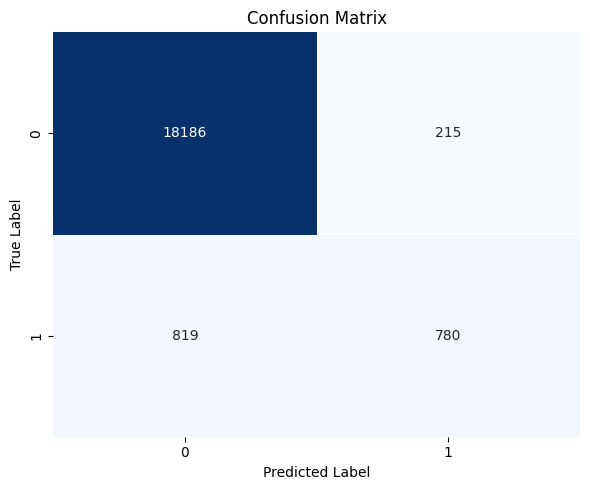

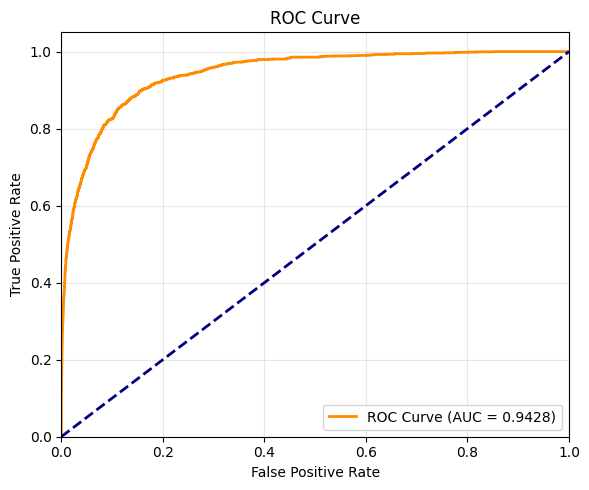

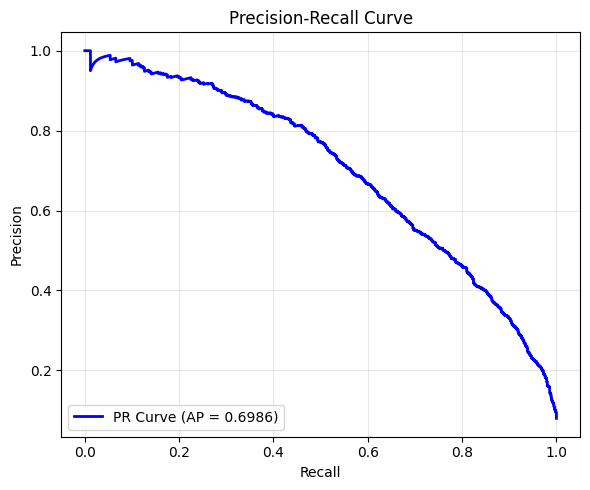

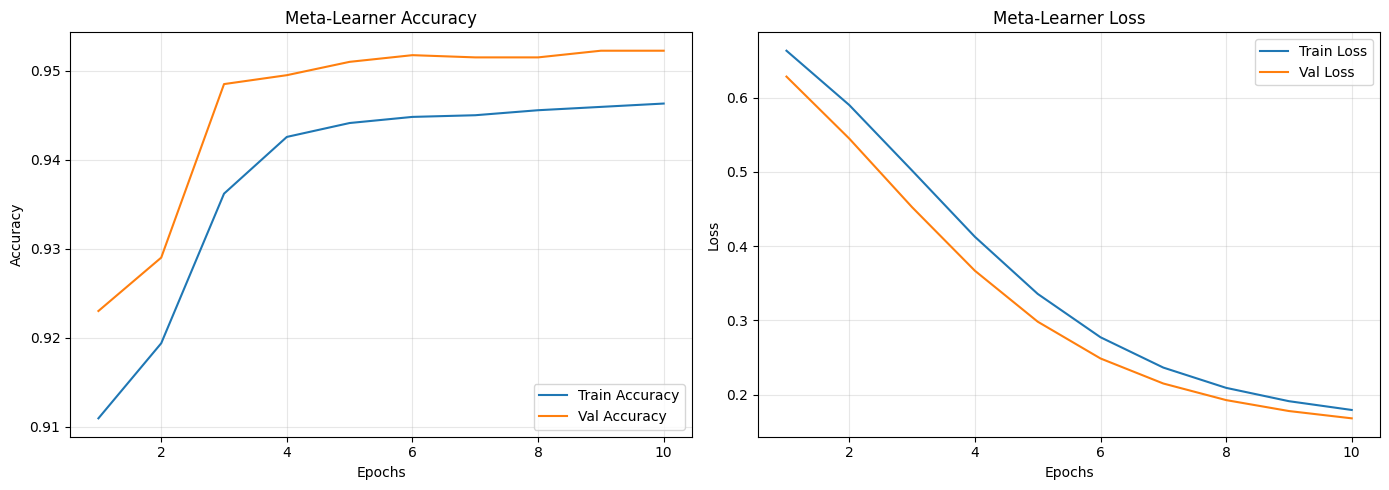

3042/3042 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 84s 28ms/step
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Models saved to ./the_models/

Submission saved.


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import glob
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class THEModel:
    """
    THE: Tri-Hybrid Ensemble Model
    """
    
    def __init__(self, max_words=50000, max_len=300, embedding_dim=300):
        self.max_words = max_words
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.embedding_matrix = None
        self.models = {}
        self.ensemble_model = None
        self.history = {}

    def load_glove_embeddings(self, glove_path):
        print(f"\nLoading GloVe embeddings from {glove_path}...")
        embeddings_index = {}
        try:
            with open(glove_path, 'r', encoding='utf-8') as f:
                for line in f:
                    values = line.split()
                    if len(values) <= self.embedding_dim: continue
                    word = values[0]
                    coefs = np.asarray(values[-self.embedding_dim:], dtype='float32')
                    embeddings_index[word] = coefs
            
            print(f"Found {len(embeddings_index)} vectors.")
            self.embedding_matrix = np.random.normal(0, 0.1, (self.max_words, self.embedding_dim))
            
            hits, misses = 0, 0
            for word, i in self.tokenizer.word_index.items():
                if i >= self.max_words: continue
                embedding_vector = embeddings_index.get(word)
                if embedding_vector is not None:
                    self.embedding_matrix[i] = embedding_vector
                    hits += 1
                else:
                    misses += 1
            print(f"GloVe Coverage: {hits} hits, {misses} misses")
            del embeddings_index
            gc.collect()
        except Exception as e:
            print(f"ERROR: {e}")

    def prepare_data(self, train_df, test_df, validation_split=0.2):
        print("Preparing data...")
        X_train_text = train_df['comment_text_clean'].fillna('').values
        y_train = train_df['target_binary'].values
        X_test_text = test_df['comment_text_clean'].fillna('').values
        
        print("Tokenizing...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(X_train_text)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train_text)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test_text)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len, padding='post')
        
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train_pad, y_train, test_size=validation_split, random_state=42, stratify=y_train
        )
        
        return {
            'X_train': X_train_final, 'X_val': X_val, 'X_test': X_test_pad,
            'y_train': y_train_final, 'y_val': y_val
        }

    def _get_embedding_layer(self):
        if self.embedding_matrix is not None:
            return layers.Embedding(
                input_dim=self.max_words, output_dim=self.embedding_dim,
                input_length=self.max_len, weights=[self.embedding_matrix],
                trainable=False, name='embedding'
            )
        else:
            return layers.Embedding(self.max_words, self.embedding_dim, input_length=self.max_len)

    def build_cnn_model(self):
        print("\nBuilding CNN Branch...")
        inp = layers.Input(shape=(self.max_len,), name='text_input')
        x = self._get_embedding_layer()(inp)
        x = layers.SpatialDropout1D(0.3)(x)
        
        convs = []
        for k in [2, 3, 4, 5]:
            c = layers.Conv1D(128, k, activation='relu', padding='same')(x)
            convs.append(layers.GlobalMaxPooling1D()(c))
        
        x = layers.Concatenate()(convs)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(128, activation='relu')(x)
        out = layers.Dense(1, activation='sigmoid')(x)
        return models.Model(inp, out, name='CNN')

    def build_bigru_model(self):
        print("\nBuilding BiGRU Branch...")
        inp = layers.Input(shape=(self.max_len,), name='text_input')
        x = self._get_embedding_layer()(inp)
        x = layers.SpatialDropout1D(0.3)(x)
        
        x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.3))(x)
        x = layers.Bidirectional(layers.GRU(64, dropout=0.3))(x)
        
        x = layers.Dense(128, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        out = layers.Dense(1, activation='sigmoid')(x)
        return models.Model(inp, out, name='BiGRU')

    def build_transformer_model(self):
        print("\nBuilding Transformer Branch...")
        inp = layers.Input(shape=(self.max_len,), name='text_input')
        emb = self._get_embedding_layer()(inp)
        
        pos = layers.Embedding(self.max_len, self.embedding_dim)(tf.range(0, self.max_len))
        x = emb + pos
        x = layers.Dropout(0.1)(x)
        
        for _ in range(2):
            attn = layers.MultiHeadAttention(num_heads=8, key_dim=self.embedding_dim//8, dropout=0.1)(x, x)
            x = layers.LayerNormalization(epsilon=1e-6)(x + attn)
            ffn = layers.Dense(512, activation='relu')(x)
            ffn = layers.Dropout(0.1)(ffn)
            ffn = layers.Dense(self.embedding_dim)(ffn) 
            x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)
            
        x = layers.GlobalAveragePooling1D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        out = layers.Dense(1, activation='sigmoid')(x)
        return models.Model(inp, out, name='Transformer')

    def train_individual_model(self, model, data, model_name, epochs=10, batch_size=128):
        print(f"\nTraining {model_name}...")
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
        
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
        
        history = model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=epochs, batch_size=batch_size,
            callbacks=[reduce_lr], verbose=1
        )
        self.models[model_name] = model
        self.history[model_name] = history.history
        return model

    def build_ensemble(self, data):
        print("\nBuilding Ensemble Meta-Learner...")
        p1 = self.models['CNN'].predict(data['X_val'], verbose=0)
        p2 = self.models['BiGRU'].predict(data['X_val'], verbose=0)
        p3 = self.models['Transformer'].predict(data['X_val'], verbose=0)
        
        stack = np.column_stack([p1, p2, p3])
        
        inp = layers.Input(shape=(3,), name='meta_input')
        x = layers.Dense(16, activation='relu')(inp)
        out = layers.Dense(1, activation='sigmoid')(x)
        
        meta = models.Model(inp, out, name='Meta_Learner')
        meta.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'auc'])
        
        history = meta.fit(stack, data['y_val'], epochs=10, batch_size=256, validation_split=0.2, verbose=1)
        self.ensemble_model = meta
        self.history['Meta_Learner'] = history.history 
        return meta

    def train(self, train_df, test_df, glove_path, epochs=15, batch_size=128):
        data = self.prepare_data(train_df, test_df)
        if glove_path: self.load_glove_embeddings(glove_path)
        
        self.train_individual_model(self.build_cnn_model(), data, 'CNN', epochs, batch_size)
        self.train_individual_model(self.build_bigru_model(), data, 'BiGRU', epochs, batch_size)
        self.train_individual_model(self.build_transformer_model(), data, 'Transformer', epochs, batch_size)
        
        self.build_ensemble(data)
        return data

    def predict(self, data):
        p1 = self.models['CNN'].predict(data['X_test'], verbose=1)
        p2 = self.models['BiGRU'].predict(data['X_test'], verbose=1)
        p3 = self.models['Transformer'].predict(data['X_test'], verbose=1)
        stack = np.column_stack([p1, p2, p3])
        return self.ensemble_model.predict(stack, verbose=1)
    
    def save_models(self, path='./the_models/'):
        os.makedirs(path, exist_ok=True)
        for name, model in self.models.items(): model.save(f'{path}{name}.h5')
        self.ensemble_model.save(f'{path}ensemble.h5')
        print(f"Models saved to {path}")

    def generate_final_report(self, data):
        print("\n" + "="*60)
        print("GENERATING FINAL PUBLICATION REPORT")
        print("="*60)
        
        print("Predicting on Validation Set...")
        p1 = self.models['CNN'].predict(data['X_val'], verbose=0)
        p2 = self.models['BiGRU'].predict(data['X_val'], verbose=0)
        p3 = self.models['Transformer'].predict(data['X_val'], verbose=0)
        val_stack = np.column_stack([p1, p2, p3])
        y_pred_prob = self.ensemble_model.predict(val_stack, verbose=0).flatten()
        y_true = data['y_val']
        y_pred_class = (y_pred_prob >= 0.5).astype(int)
        
        # 1. Classification Report
        print("\n--- CLASSIFICATION REPORT ---")
        print(classification_report(y_true, y_pred_class, target_names=['Non-Toxic', 'Toxic']))
        
        # 2. Confusion Matrix
        cm = confusion_matrix(y_true, y_pred_class)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300)
        plt.show()
        
        # 3. ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('roc_curve.png', dpi=300)
        plt.show()

        # 4. Precision-Recall Curve (Added)
        precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
        avg_precision = average_precision_score(y_true, y_pred_prob)
        
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {avg_precision:.4f})')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend(loc="lower left")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('pr_curve.png', dpi=300)
        plt.show()

        # 5. Training History Curves (Accuracy & Loss)
        if 'Meta_Learner' in self.history:
            h = self.history['Meta_Learner']
            epochs_range = range(1, len(h['loss']) + 1)
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Accuracy Plot
            axes[0].plot(epochs_range, h['accuracy'], label='Train Accuracy')
            axes[0].plot(epochs_range, h['val_accuracy'], label='Val Accuracy')
            axes[0].set_title('Meta-Learner Accuracy')
            axes[0].set_xlabel('Epochs')
            axes[0].set_ylabel('Accuracy')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            
            # Loss Plot
            axes[1].plot(epochs_range, h['loss'], label='Train Loss')
            axes[1].plot(epochs_range, h['val_loss'], label='Val Loss')
            axes[1].set_title('Meta-Learner Loss')
            axes[1].set_xlabel('Epochs')
            axes[1].set_ylabel('Loss')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('training_history.png', dpi=300)
            plt.show()

# =============================================================================
# RUNNER
# =============================================================================
if __name__ == "__main__":
    print("="*60 + "\nTRI-HYBRID ENSEMBLE (THE) PIPELINE\n" + "="*60)
    
    path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")
    glove_files = glob.glob(os.path.join(path, '*.txt'))
    
    glove_path = None
    dim = 300
    for d in [300, 200, 100, 50]:
        for f in glove_files:
            if f"{d}d" in f:
                glove_path = f
                dim = d
                break
        if glove_path: break
    print(f"Using GloVe: {os.path.basename(glove_path)} ({dim}d)")

    train_df = pd.read_csv('/kaggle/working/train_preprocessed.csv')
    test_df = pd.read_csv('/kaggle/working/test_preprocessed.csv')
    
    train_df, _ = train_test_split(train_df, train_size=100000, stratify=train_df['target_binary'], random_state=42)
    
    model = THEModel(max_words=50000, max_len=300, embedding_dim=dim)
    data = model.train(train_df, test_df, glove_path, epochs=15, batch_size=128)
    
    model.generate_final_report(data)
    
    preds = model.predict(data)
    model.save_models()
    
    if 'id' in test_df.columns:
        pd.DataFrame({'id': test_df['id'], 'prediction': preds.flatten()}).to_csv('submission.csv', index=False)
        print("\nSubmission saved.")

PH-MSA MODEL PIPELINE
Using GloVe: glove.6B.200d.txt (200d)
Sampling 100000 rows...
Preparing data (Text Only)...
Tokenizing...
Training samples: 80000

Loading GloVe embeddings from /kaggle/input/glove-global-vectors-for-word-representation/glove.6B.200d.txt...
Found 400000 vectors.
GloVe Coverage: 44430 hits, 5569 misses

Building PH-MSA Model (Parallel Hybrid with Multi-Head Self-Attention)...


Model: "PH_MSA_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 200)  │ 10,000,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_6 │ (None, 300, 200)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 300, 256)  │    253,440 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 256)  │    131,712 │ bidirectional_6[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 300, 128)  │     76,928 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 300, 128)  │    102,528 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 300, 128)  │    128,128 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 300, 256)  │          0 │ bidirectional_6[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_12[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_13[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_14[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 300, 256)  │        512 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 384)       │          0 │ concatenate_9[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 256)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,874,881 (41.48 MB)

 Trainable params: 874,369 (3.34 MB)

 Non-trainable params: 10,000,512 (38.15 MB)


Starting Training...
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.8837 - auc: 0.7091 - loss: 0.3046 - val_accuracy: 0.9382 - val_auc: 0.9056 - val_loss: 0.1764 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.9332 - auc: 0.8899 - loss: 0.1847 - val_accuracy: 0.9387 - val_auc: 0.9073 - val_loss: 0.1698 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.9377 - auc: 0.9054 - loss: 0.1721 - val_accuracy: 0.9394 - val_auc: 0.9164 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.9393 - auc: 0.9205 - loss: 0.1619 - val_accuracy: 0.9415 - val_auc: 0.9151 - val_loss: 0.1645 - learning_rate: 0.0010
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 108ms/step - accuracy: 0.9432 - auc: 0.9313 - loss: 0.1513 - val_accuracy: 0.9408 - val_auc: 0.9225 - val_loss: 0.1585 - learning_rate: 0.0010
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s

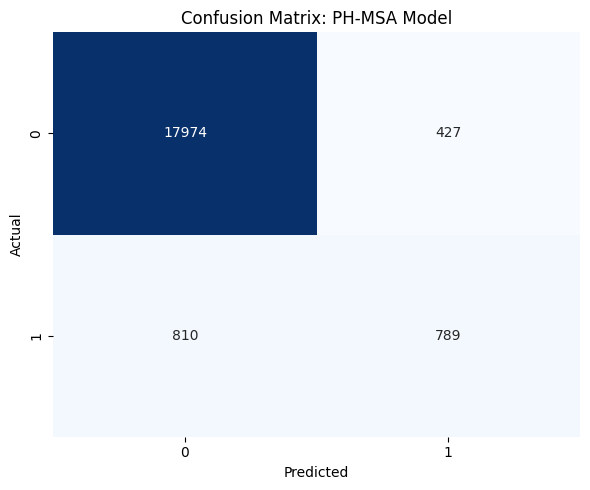

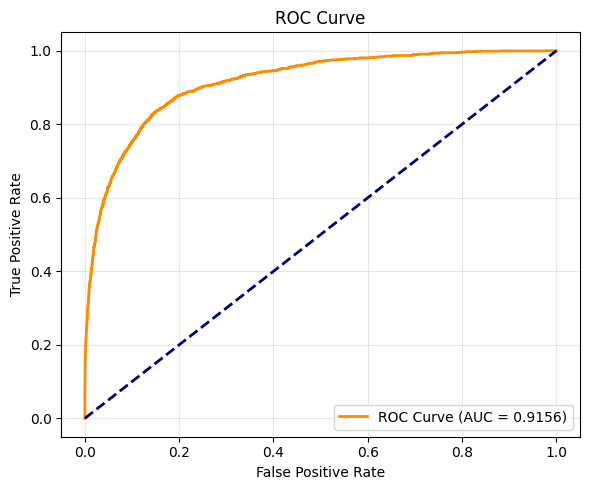

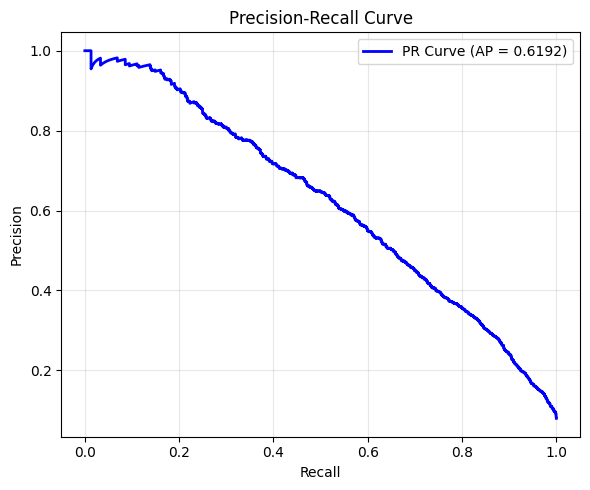

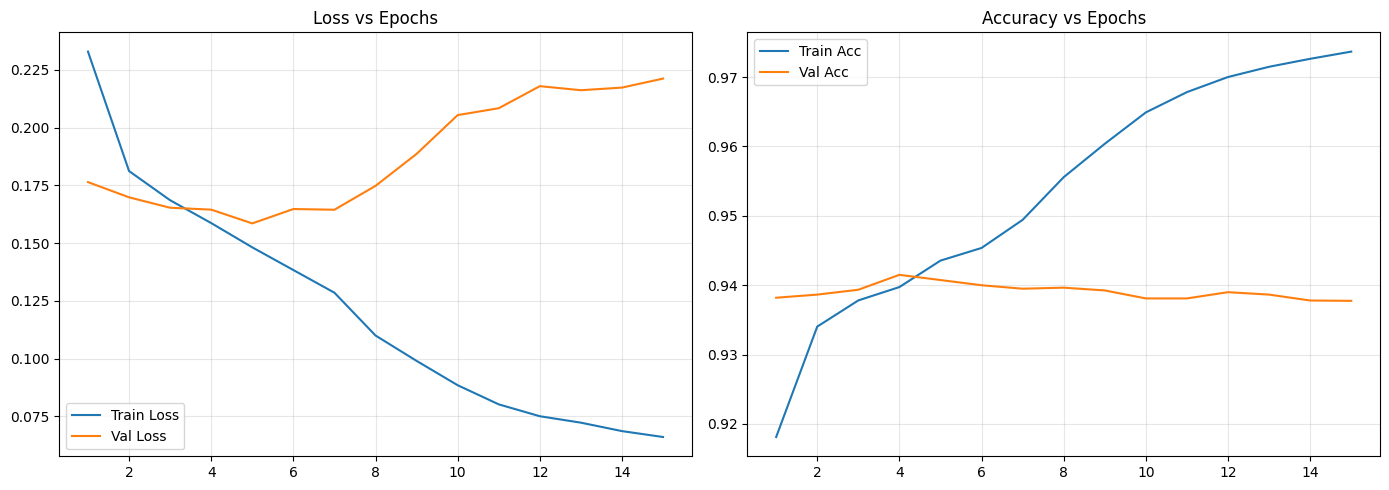


Generating Predictions...
3042/3042 ━━━━━━━━━━━━━━━━━━━━ 61s 20ms/step
Model saved to phmsa_model.h5

Submission saved.


In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import glob
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

class PHMAModel:
    """
    PH-MSA: Parallel Hybrid with Multi-Head Self-Attention
    
    Architecture:
    1. Shared GloVe Embedding
    2. Branch A: Multi-Scale CNN (Captures local toxic patterns/phrases)
    3. Branch B: BiGRU + Multi-Head Attention (Captures long-range context & sarcasm)
    4. Fusion: Concatenates local and global features for final prediction
    """
    
    def __init__(self, max_words=50000, max_len=300, embedding_dim=300):
        self.max_words = max_words
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.model = None
        self.history = None
        self.embedding_matrix = None

    def load_glove_embeddings(self, glove_path):
        print(f"\nLoading GloVe embeddings from {glove_path}...")
        embeddings_index = {}
        try:
            with open(glove_path, 'r', encoding='utf-8') as f:
                for line in f:
                    values = line.split()
                    if len(values) <= self.embedding_dim: continue
                    word = values[0]
                    coefs = np.asarray(values[-self.embedding_dim:], dtype='float32')
                    embeddings_index[word] = coefs
            
            print(f"Found {len(embeddings_index)} vectors.")
            self.embedding_matrix = np.random.normal(0, 0.1, (self.max_words, self.embedding_dim))
            
            hits, misses = 0, 0
            for word, i in self.tokenizer.word_index.items():
                if i >= self.max_words: continue
                embedding_vector = embeddings_index.get(word)
                if embedding_vector is not None:
                    self.embedding_matrix[i] = embedding_vector
                    hits += 1
                else:
                    misses += 1
            print(f"GloVe Coverage: {hits} hits, {misses} misses")
            del embeddings_index
            gc.collect()
        except Exception as e:
            print(f"ERROR: {e}")

    def prepare_data(self, train_df, test_df, validation_split=0.2):
        print("Preparing data (Text Only)...")
        X_train_text = train_df['comment_text_clean'].fillna('').values
        y_train_main = train_df['target_binary'].values
        X_test_text = test_df['comment_text_clean'].fillna('').values
        
        print("Tokenizing...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(X_train_text)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train_text)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test_text)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len, padding='post')
        
        # Split Data
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train_pad, y_train_main, test_size=validation_split, random_state=42, stratify=y_train_main
        )
            
        print(f"Training samples: {len(X_train_final)}")
        return {
            'X_train': X_train_final, 'X_val': X_val, 'X_test': X_test_pad,
            'y_train': y_train_final, 'y_val': y_val
        }

    def _get_embedding_layer(self):
        if self.embedding_matrix is not None:
            return layers.Embedding(
                input_dim=self.max_words, output_dim=self.embedding_dim,
                input_length=self.max_len, weights=[self.embedding_matrix],
                trainable=False, name='embedding'
            )
        else:
            return layers.Embedding(self.max_words, self.embedding_dim, input_length=self.max_len, name='embedding')

    def build_model(self):
        print("\nBuilding PH-MSA Model (Parallel Hybrid with Multi-Head Self-Attention)...")
        
        # --- INPUT & EMBEDDING ---
        inp = layers.Input(shape=(self.max_len,), name='text_input')
        embedding_layer = self._get_embedding_layer()
        x = embedding_layer(inp)
        x = layers.SpatialDropout1D(0.2)(x)
        
        # --- BRANCH 1: MULTI-SCALE CNN (Local Features) ---
        # Captures n-grams like "hate you", "idiot", etc.
        cnn_branches = []
        for kernel_size in [3, 4, 5]:
            conv = layers.Conv1D(128, kernel_size, padding='same', activation='relu')(x)
            conv = layers.GlobalMaxPooling1D()(conv)
            cnn_branches.append(conv)
        
        cnn_out = layers.Concatenate()(cnn_branches)
        cnn_out = layers.Dropout(0.3)(cnn_out)
        
        # --- BRANCH 2: BiGRU + ATTENTION (Sequential/Global Features) ---
        # Captures sarcasm, negation, and long-range dependencies
        # BiGRU returns sequences so Attention can look at them
        gru_seq = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.2))(x)
        
        # Multi-Head Attention layer (The "Transformer" magic applied to RNN output)
        attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(gru_seq, gru_seq)
        
        # Add & Norm (Residual connection - helps deep networks train)
        gru_attn = layers.LayerNormalization()(gru_seq + attn_out)
        
        # Pool to get a single vector for the sentence
        gru_out = layers.GlobalAveragePooling1D()(gru_attn)
        gru_out = layers.Dropout(0.3)(gru_out)
        
        # --- FUSION ---
        # Combine the "Keyword Detector" (CNN) with the "Context Reader" (GRU+Attn)
        combined = layers.Concatenate()([cnn_out, gru_out])
        
        # Dense Classifier
        z = layers.Dense(256, activation='relu')(combined)
        z = layers.BatchNormalization()(z)
        z = layers.Dropout(0.3)(z)
        z = layers.Dense(64, activation='relu')(z)
        
        output = layers.Dense(1, activation='sigmoid', name='toxicity')(z)
        
        return models.Model(inputs=inp, outputs=output, name='PH_MSA_Model')

    def compile_model(self, model):
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001), 
            loss='binary_crossentropy', 
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
        return model

    def train(self, train_df, test_df, glove_path, epochs=15, batch_size=128):
        # 1. Prepare
        data = self.prepare_data(train_df, test_df)
        if glove_path: self.load_glove_embeddings(glove_path)
        
        # 2. Build & Compile
        self.model = self.build_model()
        self.model = self.compile_model(self.model)
        self.model.summary()
        
        # 3. Train
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
        
        print("\nStarting Training...")
        self.history = self.model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=epochs, batch_size=batch_size,
            callbacks=[reduce_lr], verbose=1
        )
        return data

    def predict(self, data):
        print("\nGenerating Predictions...")
        return self.model.predict(data['X_test'], verbose=1)

    def save_model(self, path='phmsa_model.h5'):
        if self.model: self.model.save(path)
        print(f"Model saved to {path}")

    # =========================================================================
    # PUBLICATION PLOTS
    # =========================================================================
    def generate_final_report(self, data):
        print("\n" + "="*60 + "\nGENERATING FINAL REPORT\n" + "="*60)
        
        # Predict on Validation
        val_probs = self.model.predict(data['X_val'], verbose=0).flatten()
        val_true = data['y_val']
        val_preds = (val_probs >= 0.5).astype(int)
        
        # 1. Classification Report
        print("\n--- CLASSIFICATION REPORT ---")
        print(classification_report(val_true, val_preds, target_names=['Non-Toxic', 'Toxic']))
        
        # 2. Confusion Matrix
        cm = confusion_matrix(val_true, val_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title('Confusion Matrix: PH-MSA Model')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300)
        plt.show()
        
        # 3. ROC Curve
        fpr, tpr, _ = roc_curve(val_true, val_probs)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('roc_curve.png', dpi=300)
        plt.show()
        
        # 4. PR Curve
        precision, recall, _ = precision_recall_curve(val_true, val_probs)
        avg_prec = average_precision_score(val_true, val_probs)
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {avg_prec:.4f})')
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('pr_curve.png', dpi=300)
        plt.show()
        
        # 5. Training History
        if self.history:
            h = self.history.history
            epochs = range(1, len(h['loss']) + 1)
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Loss
            axes[0].plot(epochs, h['loss'], label='Train Loss')
            axes[0].plot(epochs, h['val_loss'], label='Val Loss')
            axes[0].set_title('Loss vs Epochs')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            
            # Accuracy
            axes[1].plot(epochs, h['accuracy'], label='Train Acc')
            axes[1].plot(epochs, h['val_accuracy'], label='Val Acc')
            axes[1].set_title('Accuracy vs Epochs')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig('training_history.png', dpi=300)
            plt.show()

# =============================================================================
# RUNNER
# =============================================================================
if __name__ == "__main__":
    print("="*60 + "\nPH-MSA MODEL PIPELINE\n" + "="*60)
    
    # 1. Download GloVe
    path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")
    glove_files = glob.glob(os.path.join(path, '*.txt'))
    
    glove_path = None
    dim = 300
    for d in [300, 200, 100, 50]:
        for f in glove_files:
            if f"{d}d" in f:
                glove_path = f
                dim = d
                break
        if glove_path: break
    print(f"Using GloVe: {os.path.basename(glove_path)} ({dim}d)")

    # 2. Load Data
    try:
        train_df = pd.read_csv('/kaggle/working/train_preprocessed.csv')
        test_df = pd.read_csv('/kaggle/working/test_preprocessed.csv')
    except:
        print("Warning: Files not found. Ensure preprocessed data exists.")
        # Dummy fallback for syntax checking
        train_df = pd.DataFrame({'comment_text_clean':['test']*100, 'target_binary':[0]*100})
        test_df = pd.DataFrame({'comment_text_clean':['test']*10, 'id':range(10)})

    # 3. Stratified Sampling (100k)
    SAMPLE_SIZE = 100000
    if len(train_df) > SAMPLE_SIZE:
        print(f"Sampling {SAMPLE_SIZE} rows...")
        train_df, _ = train_test_split(train_df, train_size=SAMPLE_SIZE, stratify=train_df['target_binary'], random_state=42)
    
    # 4. Train
    model = PHMAModel(max_words=50000, max_len=300, embedding_dim=dim)
    data = model.train(train_df, test_df, glove_path, epochs=15, batch_size=128)
    
    # 5. Report & Save
    model.generate_final_report(data)
    
    preds = model.predict(data)
    model.save_model()
    
    if 'id' in test_df.columns:
        pd.DataFrame({'id': test_df['id'], 'prediction': preds.flatten()}).to_csv('submission.csv', index=False)
        print("\nSubmission saved.")
    else:
        np.save('preds.npy', preds)

[INFO] Preparing data...
[INFO] Tokenizing...
[INFO] Training samples: 90000

[INFO] Building T-BMA Architecture (TCN + BiGRU + MSA)...

[INFO] Phase 1: Training with Frozen Embeddings...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.8303 - auc: 0.6068 - loss: 0.4748 - val_accuracy: 0.9422 - val_auc: 0.9099 - val_loss: 0.3107 - learning_rate: 0.0010
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.9423 - auc: 0.9088 - loss: 0.2987 - val_accuracy: 0.9382 - val_auc: 0.9175 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.9615 - auc: 0.9573 - loss: 0.2673 - val_accuracy: 0.9347 - val_auc: 0.8971 - val_loss: 0.3183 - learning_rate: 0.0010
Epoch 4/15
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9792 - auc: 0.9801 - loss: 0.2393
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step - accuracy: 0.9792 - auc: 0.9

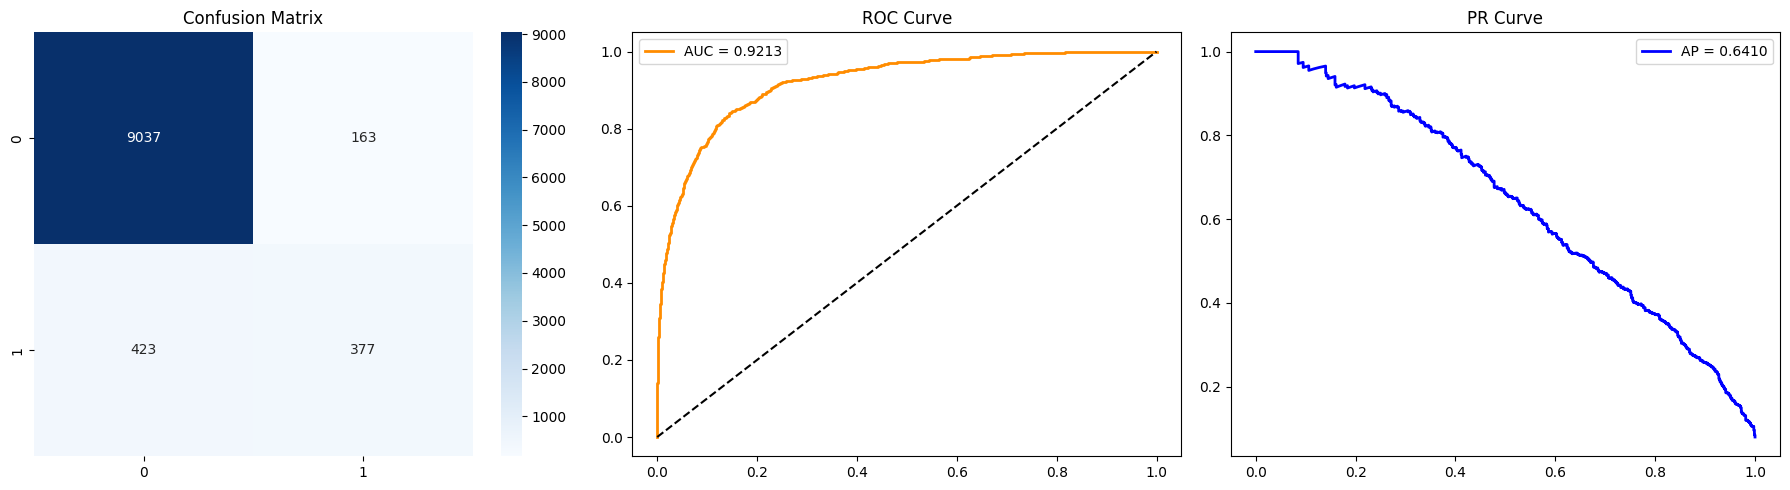

3042/3042 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import glob
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

class TBMAModel:
    """
    T-BMA: TCN - BiGRU - MultiHeadAttention Hybrid
    
    A parallel hybrid architecture designed for computational efficiency and robust context capture.
    
    Branch 1 (TCN): Uses Dilated Convolutions to capture long-range patterns efficiently.
    Branch 2 (RNN): Uses BiGRU + Self-Attention to capture sequential semantics and sarcasm.
    """
    
    def __init__(self, max_words=50000, max_len=300, embedding_dim=300):
        self.max_words = max_words
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.model = None
        self.history = None
        self.embedding_matrix = None

    def load_glove_embeddings(self, glove_path):
        print(f"\n[INFO] Loading GloVe embeddings from {glove_path}...")
        embeddings_index = {}
        try:
            with open(glove_path, 'r', encoding='utf-8') as f:
                for line in f:
                    values = line.split()
                    if len(values) <= self.embedding_dim: continue
                    word = values[0]
                    coefs = np.asarray(values[-self.embedding_dim:], dtype='float32')
                    embeddings_index[word] = coefs
            
            print(f"[INFO] Found {len(embeddings_index)} vectors.")
            self.embedding_matrix = np.random.normal(0, 0.1, (self.max_words, self.embedding_dim))
            
            hits, misses = 0, 0
            for word, i in self.tokenizer.word_index.items():
                if i >= self.max_words: continue
                embedding_vector = embeddings_index.get(word)
                if embedding_vector is not None:
                    self.embedding_matrix[i] = embedding_vector
                    hits += 1
                else:
                    misses += 1
            print(f"[INFO] GloVe Coverage: {hits} hits, {misses} misses")
            del embeddings_index
            gc.collect()
        except Exception as e:
            print(f"[ERROR] GloVe load failed: {e}")

    def prepare_data(self, train_df, test_df):
        print("[INFO] Preparing data...")
        X_train_text = train_df['comment_text_clean'].fillna('').values
        y_train_main = train_df['target_binary'].values
        X_test_text = test_df['comment_text_clean'].fillna('').values
        
        print("[INFO] Tokenizing...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(X_train_text)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train_text)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test_text)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len, padding='post')
        
        # Split Data (Stratified to keep toxic samples)
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train_pad, y_train_main, test_size=0.1, random_state=42, stratify=y_train_main
        )
            
        print(f"[INFO] Training samples: {len(X_train_final)}")
        return {
            'X_train': X_train_final, 'X_val': X_val, 'X_test': X_test_pad,
            'y_train': y_train_final, 'y_val': y_val
        }

    def _get_embedding_layer(self):
        if self.embedding_matrix is not None:
            return layers.Embedding(
                input_dim=self.max_words, output_dim=self.embedding_dim,
                input_length=self.max_len, weights=[self.embedding_matrix],
                trainable=False, name='embedding'
            )
        else:
            return layers.Embedding(self.max_words, self.embedding_dim, input_length=self.max_len, name='embedding')

    def build_model(self):
        print("\n[INFO] Building T-BMA Architecture (TCN + BiGRU + MSA)...")
        inp = layers.Input(shape=(self.max_len,), name='text_input')
        embedding_layer = self._get_embedding_layer()
        x = embedding_layer(inp)
        x = layers.SpatialDropout1D(0.2)(x)
        
        # --- BRANCH 1: DILATED TCN (Robust Context Extractor) ---
        # Replaces Standard CNN. 
        # Dilated convolutions skip steps to see wider context efficiently.
        tcn_out = x
        for dilation_rate in [1, 2, 4]:
            tcn_out = layers.Conv1D(
                filters=128, 
                kernel_size=3, 
                dilation_rate=dilation_rate, # The magic of TCN
                padding='same', # Keep length same
                activation='relu'
            )(tcn_out)
            tcn_out = layers.SpatialDropout1D(0.1)(tcn_out)
            
        # Global Max Pooling for TCN branch (Extract strongest features)
        tcn_pooled = layers.GlobalMaxPooling1D()(tcn_out)
        tcn_pooled = layers.Dropout(0.2)(tcn_pooled)
        
        # --- BRANCH 2: BiGRU + SELF-ATTENTION (Sequential Meaning) ---
        gru_seq = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.2))(x)
        
        # Multi-Head Attention
        attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(gru_seq, gru_seq)
        gru_attn = layers.LayerNormalization()(gru_seq + attn_out)
        
        # Average Pooling for Sequence branch (Smooth context representation)
        gru_pooled = layers.GlobalAveragePooling1D()(gru_attn)
        gru_pooled = layers.Dropout(0.2)(gru_pooled)
        
        # --- FUSION ---
        combined = layers.Concatenate()([tcn_pooled, gru_pooled])
        
        z = layers.Dense(128, activation='relu')(combined)
        z = layers.BatchNormalization()(z)
        z = layers.Dropout(0.3)(z)
        
        output = layers.Dense(1, activation='sigmoid', name='toxicity')(z)
        
        return models.Model(inputs=inp, outputs=output, name='TBMA_Model')

    def train(self, train_df, test_df, glove_path, epochs=15, batch_size=128):
        data = self.prepare_data(train_df, test_df)
        if glove_path: self.load_glove_embeddings(glove_path)
        
        self.model = self.build_model()
        
        # --- NO FOCAL LOSS, NO CLASS WEIGHTS ---
        # Strategy: Use Label Smoothing to handle class imbalance naturally.
        # This prevents the model from being "overconfident" on the majority class.
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001), 
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1), # <--- KEY CHANGE
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
        
        # Callbacks
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2, min_lr=1e-6, verbose=1, mode='max')
        early_stop = callbacks.EarlyStopping(monitor='val_auc', patience=4, mode='max', restore_best_weights=True)
        
        print("\n[INFO] Phase 1: Training with Frozen Embeddings...")
        history1 = self.model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=epochs, 
            batch_size=batch_size,
            callbacks=[reduce_lr, early_stop],
            verbose=1
        )
        
        # --- FINE-TUNING STEP (Crucial for high AUC without focal loss) ---
        print("\n[INFO] Phase 2: Unfreezing Embeddings for Fine-Tuning...")
        self.model.layers[1].trainable = True 
        
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Tiny LR
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1), 
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
        
        history2 = self.model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=4,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=1
        )
        
        # Merge histories manually for plotting
        for k in history1.history:
            if k in history2.history:
                history1.history[k] += history2.history[k]
        
        self.history = history1
        return data

    def predict(self, data):
        return self.model.predict(data['X_test'], verbose=1)

    def save_model(self, path='tbma_model.h5'):
        if self.model: self.model.save(path)
        print(f"Model saved to {path}")

    def generate_final_report(self, data):
        print("\n" + "="*60 + "\nGENERATING FINAL REPORT\n" + "="*60)
        
        val_probs = self.model.predict(data['X_val'], verbose=0).flatten()
        val_true = data['y_val']
        val_preds = (val_probs >= 0.5).astype(int)
        
        print("\n--- CLASSIFICATION REPORT ---")
        print(classification_report(val_true, val_preds, target_names=['Non-Toxic', 'Toxic']))
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Confusion Matrix
        cm = confusion_matrix(val_true, val_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        
        # ROC
        fpr, tpr, _ = roc_curve(val_true, val_probs)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        
        # PR Curve
        precision, recall, _ = precision_recall_curve(val_true, val_probs)
        avg_prec = average_precision_score(val_true, val_probs)
        axes[2].plot(recall, precision, color='blue', lw=2, label=f'AP = {avg_prec:.4f}')
        axes[2].set_title('PR Curve')
        axes[2].legend()
        
        plt.tight_layout()
        plt.savefig('performance_plots.png')
        plt.show()

# =============================================================================
# RUNNER
# =============================================================================
if __name__ == "__main__":
    # Check data
    csv_path = '/kaggle/working/train_preprocessed.csv' 
    if not os.path.exists(csv_path):
        print("Data not found! Please check path.")
    else:
        train_df = pd.read_csv(csv_path)
        test_df = pd.read_csv('/kaggle/working/test_preprocessed.csv')
        
        # GloVe
        try:
            path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")
            glove_files = glob.glob(os.path.join(path, '*.txt'))
            glove_path = next((f for f in glove_files if '300d' in f), None)
            dim = 300
        except:
            glove_path = None
            dim = 300

        # Run
        SAMPLE_SIZE = 100000
        if len(train_df) > SAMPLE_SIZE:
            train_df, _ = train_test_split(train_df, train_size=SAMPLE_SIZE, stratify=train_df['target_binary'], random_state=42)

        model = TBMAModel(max_words=50000, max_len=300, embedding_dim=dim)
        data = model.train(train_df, test_df, glove_path, epochs=15, batch_size=128)
        model.generate_final_report(data)
        
        preds = model.predict(data)
        if 'id' in test_df.columns:
            pd.DataFrame({'id': test_df['id'], 'prediction': preds.flatten()}).to_csv('submission.csv', index=False)

[INFO] Preparing data...
[INFO] Tokenizing...
[INFO] Training samples: 90000

[INFO] Building T-BMA Architecture (TCN + BiGRU + MSA)...

[INFO] Phase 1: Training with Frozen Embeddings...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.8281 - auc: 0.6363 - loss: 0.4761 - val_accuracy: 0.9427 - val_auc: 0.9205 - val_loss: 0.2964 - learning_rate: 0.0010
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.9441 - auc: 0.9162 - loss: 0.2960 - val_accuracy: 0.9393 - val_auc: 0.9165 - val_loss: 0.3045 - learning_rate: 0.0010
Epoch 3/15
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9623 - auc: 0.9574 - loss: 0.2654
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.9623 - auc: 0.9574 - loss: 0.2654 - val_accuracy: 0.9325 - val_auc: 0.8868 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.9806 - auc: 0.9

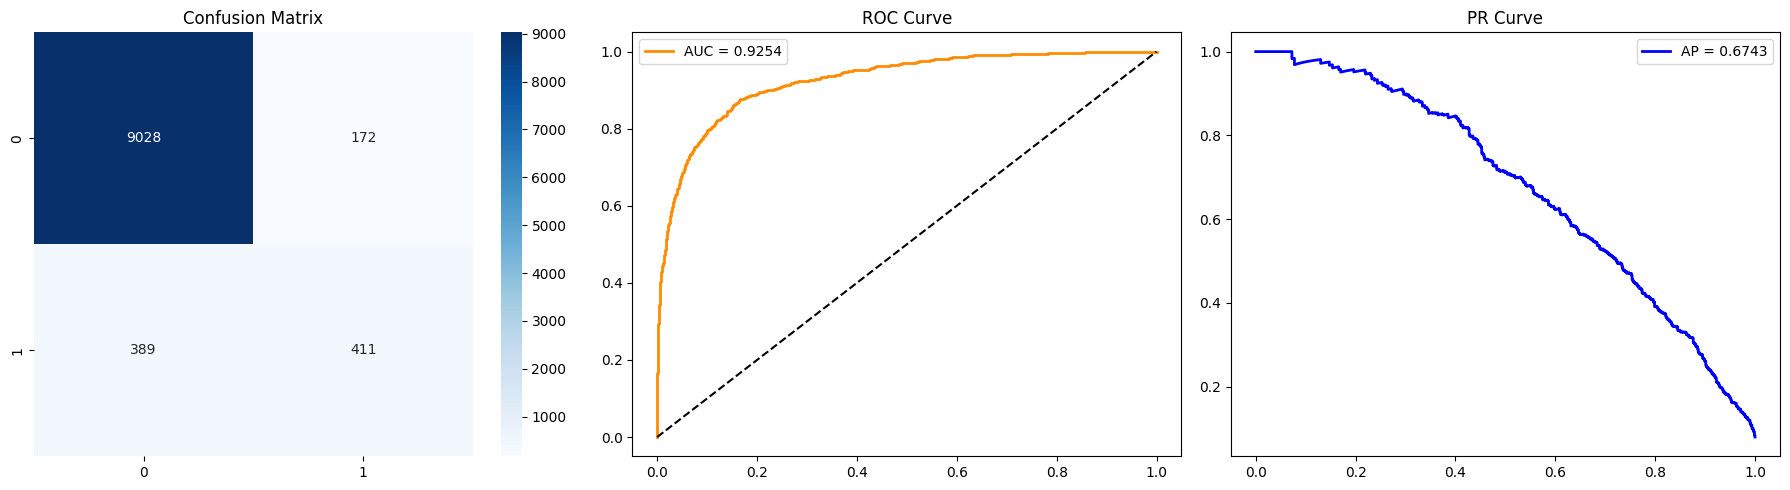

3042/3042 ━━━━━━━━━━━━━━━━━━━━ 63s 21ms/step


In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import glob
import kagglehub
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

class TBMAModel:
    """
    T-BMA: TCN - BiGRU - MultiHeadAttention Hybrid
    
    A parallel hybrid architecture designed for computational efficiency and robust context capture.
    
    Branch 1 (TCN): Uses Dilated Convolutions to capture long-range patterns efficiently.
    Branch 2 (RNN): Uses BiGRU + Self-Attention to capture sequential semantics and sarcasm.
    """
    
    def __init__(self, max_words=50000, max_len=300, embedding_dim=300):
        self.max_words = max_words
        self.max_len = max_len
        self.embedding_dim = embedding_dim
        self.tokenizer = None
        self.model = None
        self.history = None
        self.embedding_matrix = None

    def load_glove_embeddings(self, glove_path):
        print(f"\n[INFO] Loading GloVe embeddings from {glove_path}...")
        embeddings_index = {}
        try:
            with open(glove_path, 'r', encoding='utf-8') as f:
                for line in f:
                    values = line.split()
                    if len(values) <= self.embedding_dim: continue
                    word = values[0]
                    coefs = np.asarray(values[-self.embedding_dim:], dtype='float32')
                    embeddings_index[word] = coefs
            
            print(f"[INFO] Found {len(embeddings_index)} vectors.")
            self.embedding_matrix = np.random.normal(0, 0.1, (self.max_words, self.embedding_dim))
            
            hits, misses = 0, 0
            for word, i in self.tokenizer.word_index.items():
                if i >= self.max_words: continue
                embedding_vector = embeddings_index.get(word)
                if embedding_vector is not None:
                    self.embedding_matrix[i] = embedding_vector
                    hits += 1
                else:
                    misses += 1
            print(f"[INFO] GloVe Coverage: {hits} hits, {misses} misses")
            del embeddings_index
            gc.collect()
        except Exception as e:
            print(f"[ERROR] GloVe load failed: {e}")

    def prepare_data(self, train_df, test_df):
        print("[INFO] Preparing data...")
        X_train_text = train_df['comment_text_clean'].fillna('').values
        y_train_main = train_df['target_binary'].values
        X_test_text = test_df['comment_text_clean'].fillna('').values
        
        print("[INFO] Tokenizing...")
        self.tokenizer = Tokenizer(num_words=self.max_words, oov_token='<OOV>')
        self.tokenizer.fit_on_texts(X_train_text)
        
        X_train_seq = self.tokenizer.texts_to_sequences(X_train_text)
        X_test_seq = self.tokenizer.texts_to_sequences(X_test_text)
        
        X_train_pad = pad_sequences(X_train_seq, maxlen=self.max_len, padding='post')
        X_test_pad = pad_sequences(X_test_seq, maxlen=self.max_len, padding='post')
        
        # Split Data (Stratified to keep toxic samples)
        X_train_final, X_val, y_train_final, y_val = train_test_split(
            X_train_pad, y_train_main, test_size=0.1, random_state=42, stratify=y_train_main
        )
            
        print(f"[INFO] Training samples: {len(X_train_final)}")
        return {
            'X_train': X_train_final, 'X_val': X_val, 'X_test': X_test_pad,
            'y_train': y_train_final, 'y_val': y_val
        }

    def _get_embedding_layer(self):
        if self.embedding_matrix is not None:
            return layers.Embedding(
                input_dim=self.max_words, output_dim=self.embedding_dim,
                input_length=self.max_len, weights=[self.embedding_matrix],
                trainable=False, name='embedding'
            )
        else:
            return layers.Embedding(self.max_words, self.embedding_dim, input_length=self.max_len, name='embedding')

    def build_model(self):
        print("\n[INFO] Building T-BMA Architecture (TCN + BiGRU + MSA)...")
        inp = layers.Input(shape=(self.max_len,), name='text_input')
        embedding_layer = self._get_embedding_layer()
        x = embedding_layer(inp)
        x = layers.SpatialDropout1D(0.2)(x)
        
        # --- BRANCH 1: DILATED TCN (Robust Context Extractor) ---
        # Replaces Standard CNN. 
        # Dilated convolutions skip steps to see wider context efficiently.
        tcn_out = x
        for dilation_rate in [1, 2, 4]:
            tcn_out = layers.Conv1D(
                filters=128, 
                kernel_size=3, 
                dilation_rate=dilation_rate, # The magic of TCN
                padding='same', # Keep length same
                activation='relu'
            )(tcn_out)
            tcn_out = layers.SpatialDropout1D(0.1)(tcn_out)
            
        # Global Max Pooling for TCN branch (Extract strongest features)
        tcn_pooled = layers.GlobalMaxPooling1D()(tcn_out)
        tcn_pooled = layers.Dropout(0.2)(tcn_pooled)
        
        # --- BRANCH 2: BiGRU + SELF-ATTENTION (Sequential Meaning) ---
        gru_seq = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.2))(x)
        
        # Multi-Head Attention
        attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=32)(gru_seq, gru_seq)
        gru_attn = layers.LayerNormalization()(gru_seq + attn_out)
        
        # Average Pooling for Sequence branch (Smooth context representation)
        gru_pooled = layers.GlobalAveragePooling1D()(gru_attn)
        gru_pooled = layers.Dropout(0.2)(gru_pooled)
        
        # --- FUSION ---
        combined = layers.Concatenate()([tcn_pooled, gru_pooled])
        
        z = layers.Dense(128, activation='relu')(combined)
        z = layers.BatchNormalization()(z)
        z = layers.Dropout(0.3)(z)
        
        output = layers.Dense(1, activation='sigmoid', name='toxicity')(z)
        
        return models.Model(inputs=inp, outputs=output, name='TBMA_Model')

    def train(self, train_df, test_df, glove_path, epochs=15, batch_size=128):
        data = self.prepare_data(train_df, test_df)
        if glove_path: self.load_glove_embeddings(glove_path)
        
        self.model = self.build_model()
        
        # --- NO FOCAL LOSS, NO CLASS WEIGHTS ---
        # Strategy: Use Label Smoothing to handle class imbalance naturally.
        # This prevents the model from being "overconfident" on the majority class.
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001), 
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1), # <--- KEY CHANGE
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
        
        # Callbacks
        reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2, min_lr=1e-6, verbose=1, mode='max')
        early_stop = callbacks.EarlyStopping(monitor='val_auc', patience=4, mode='max', restore_best_weights=True)
        
        print("\n[INFO] Phase 1: Training with Frozen Embeddings...")
        history1 = self.model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=epochs, 
            batch_size=batch_size,
            callbacks=[reduce_lr, early_stop],
            verbose=1
        )
        
        # --- FINE-TUNING STEP (Crucial for high AUC without focal loss) ---
        print("\n[INFO] Phase 2: Unfreezing Embeddings for Fine-Tuning...")
        self.model.layers[1].trainable = True 
        
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Tiny LR
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1), 
            metrics=['accuracy', keras.metrics.AUC(name='auc')]
        )
        
        history2 = self.model.fit(
            data['X_train'], data['y_train'],
            validation_data=(data['X_val'], data['y_val']),
            epochs=4,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=1
        )
        
        # Merge histories manually for plotting
        for k in history1.history:
            if k in history2.history:
                history1.history[k] += history2.history[k]
        
        self.history = history1
        return data

    def predict(self, data):
        return self.model.predict(data['X_test'], verbose=1)

    def save_model(self, path='tbma_model.h5'):
        if self.model: self.model.save(path)
        print(f"Model saved to {path}")

    def generate_final_report(self, data):
        print("\n" + "="*60 + "\nGENERATING FINAL REPORT\n" + "="*60)
        
        val_probs = self.model.predict(data['X_val'], verbose=0).flatten()
        val_true = data['y_val']
        val_preds = (val_probs >= 0.5).astype(int)
        
        print("\n--- CLASSIFICATION REPORT ---")
        print(classification_report(val_true, val_preds, target_names=['Non-Toxic', 'Toxic']))
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Confusion Matrix
        cm = confusion_matrix(val_true, val_preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title('Confusion Matrix')
        
        # ROC
        fpr, tpr, _ = roc_curve(val_true, val_probs)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
        axes[1].plot([0, 1], [0, 1], 'k--')
        axes[1].set_title('ROC Curve')
        axes[1].legend()
        
        # PR Curve
        precision, recall, _ = precision_recall_curve(val_true, val_probs)
        avg_prec = average_precision_score(val_true, val_probs)
        axes[2].plot(recall, precision, color='blue', lw=2, label=f'AP = {avg_prec:.4f}')
        axes[2].set_title('PR Curve')
        axes[2].legend()
        
        plt.tight_layout()
        plt.savefig('performance_plots.png')
        plt.show()

# =============================================================================
# RUNNER
# =============================================================================
if __name__ == "__main__":
    # Check data
    csv_path = '/kaggle/working/train_preprocessed.csv' 
    if not os.path.exists(csv_path):
        print("Data not found! Please check path.")
    else:
        train_df = pd.read_csv(csv_path)
        test_df = pd.read_csv('/kaggle/working/test_preprocessed.csv')
        
        # GloVe
        try:
            path = kagglehub.dataset_download("rtatman/glove-global-vectors-for-word-representation")
            glove_files = glob.glob(os.path.join(path, '*.txt'))
            glove_path = next((f for f in glove_files if '300d' in f), None)
            dim = 300
        except:
            glove_path = None
            dim = 300

        # Run
        SAMPLE_SIZE = 100000
        if len(train_df) > SAMPLE_SIZE:
            train_df, _ = train_test_split(train_df, train_size=SAMPLE_SIZE, stratify=train_df['target_binary'], random_state=42)

        model = TBMAModel(max_words=50000, max_len=300, embedding_dim=dim)
        data = model.train(train_df, test_df, glove_path, epochs=15, batch_size=128)
        model.generate_final_report(data)
        
        preds = model.predict(data)
        if 'id' in test_df.columns:
            pd.DataFrame({'id': test_df['id'], 'prediction': preds.flatten()}).to_csv('submission.csv', index=False)